# ACM : Análisis de Correspondencia Múltiple  


# 1. Introducción

## ¿Qué es el Análisis de Correspondencia Múltiple (ACM)?

El **Análisis de Correspondencia Múltiple (ACM)** es una técnica estadística multivariada de **reducción de dimensionalidad** diseñada para analizar de forma conjunta **múltiples variables categóricas**. Puede entenderse como una extensión del Análisis de Correspondencias Simple y como una alternativa al PCA cuando la información no es numérica continua, sino cualitativa.

El ACM transforma las categorías de varias variables en un **espacio factorial de baja dimensión**, en el cual:

- las categorías que tienden a aparecer juntas en los individuos se ubican **cerca** entre sí,
- las categorías poco asociadas o contrastantes aparecen **alejadas**,
- y los individuos con perfiles similares pueden agruparse en regiones próximas del plano.

Esto permite sintetizar estructuras complejas de asociación y facilitar la interpretación de patrones presentes en la población analizada.

---

## ¿Qué problema resuelve en este estudio?

La base de datos del **Sisbén IV** contiene múltiples variables categóricas relacionadas con las condiciones de vida de las personas. En particular, este estudio se concentra en variables asociadas con:

- **educación** (`per015`, `per016`, `per017`),
- **actividad e inserción laboral** (`per018`, `per019`, `per020`),
- y **contexto territorial** (`zona`).

Estas variables no pueden analizarse adecuadamente con técnicas tradicionales como el **Análisis de Componentes Principales (PCA)**, ya que no poseen una estructura métrica continua. El ACM resuelve este problema al representar las categorías en un espacio numérico interpretable, preservando sus relaciones de asociación.

En este contexto, el ACM permite:

| Desafío | Aporte del ACM |
|--------|----------------|
| Variables cualitativas | Representa sus categorías en un espacio geométrico interpretable |
| Múltiples variables sociales interrelacionadas | Resume la información en pocas dimensiones |
| Dificultad para detectar perfiles sociales | Permite identificar agrupamientos y asociaciones entre categorías |
| Relación entre educación y empleo | Facilita construir tipologías educativo-laborales |
| Diferencias territoriales | Permite interpretar el papel de la zona como factor ilustrativo |

Así, el ACM constituye una herramienta adecuada para explorar la estructura de los **perfiles educativo-laborales** de la población y su relación con condiciones socioeconómicas observables en el Sisbén IV.

---

## Objetivo general

Identificar perfiles educativo-laborales de la población registrada en el Sisbén IV mediante Análisis de Correspondencia Múltiple, a partir de variables categóricas de educación, actividad laboral y posición ocupacional.

---

## Objetivos específicos

1. Analizar las asociaciones entre **nivel educativo**, **participación en estudio**, **actividad principal**, **posición ocupacional** y **cotización a pensión**.
2. Identificar **perfiles de inserción laboral** asociados con diferentes trayectorias educativas.
3. Describir la distribución de dichos perfiles según variables ilustrativas como **zona**, **sexo**, **edad** y **clasificación Sisbén**.
4. Explorar si los perfiles identificados se relacionan con condiciones de mayor vulnerabilidad social, como la **pobreza multidimensional proxy**.

---

## Preguntas guía

1. **¿Qué asociaciones existen entre las variables educativas y laborales de la población Sisbén IV?**
2. **¿Qué perfiles educativo-laborales pueden identificarse a partir del ACM?**
3. **¿Qué categorías aparecen más próximas entre sí en el espacio factorial y qué tipo de población representan?**
4. **¿Cómo se distribuyen los perfiles identificados según zona urbano-rural, sexo y grupos de edad?**
5. **¿Existe relación entre ciertos perfiles educativo-laborales y condiciones de vulnerabilidad social?**

## Contexto de los Datos:

### Dicionario de Variables
El **Departamento Nacional de Planeación (DNP)** publica muestras anonimizadas del Sisbén IV con información de personas, viviendas y hogares a nivel nacional.

| Variable        | Nombre                                                                         | Tipo estadístico | Formato   | Ancho | Decimales | Rango / valores          | Descripción completa                                                                                                                                                                                                                                                                                                                                                                                                                                                            | Tipo lógico                   |
| --------------- | ------------------------------------------------------------------------------ | ---------------: | --------- | ----: | --------: | ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------- |
| `cod_mpio`      | Código municipio                                                               |         Continua | numeric   |     5 |         0 | 5001–99773               | Código del municipio.                                                                                                                                                                                                                                                                                                                                                                                                                                                           | Identificadora                |
| `llave`         | Consecutivo de vivienda                                                        |         Continua | numeric   |     4 |         0 | 1–3401                   | Identificador consecutivo de la vivienda.                                                                                                                                                                                                                                                                                                                                                                                                                                       | Identificadora                |
| `hogar`         | Consecutivo de hogar                                                           |         Discreta | numeric   |     2 |         0 | 1–15                     | Identificador consecutivo del hogar dentro de la vivienda.                                                                                                                                                                                                                                                                                                                                                                                                                      | Identificadora                |
| `orden`         | Consecutivo de personas                                                        |         Discreta | numeric   |     2 |         0 | 1–21                     | Identificador consecutivo de la persona dentro del hogar.                                                                                                                                                                                                                                                                                                                                                                                                                       | Identificadora                |
| `zona`          | Zona                                                                           |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Cabecera; 2 = Centro Poblado, Rural Disperso.                                                                                                                                                                                                                                                                                                                                                                                                                               | Categórica                    |
| `fex`           | Factor de expansión                                                            |         Continua | numeric   |    12 |         0 | 1.037037037–1842.6678201 | Factor de expansión de la observación.                                                                                                                                                                                                                                                                                                                                                                                                                                          | Continua                      |
| `corte`         | Corte                                                                          |         Discreta | character |     8 |         — | Texto                    | Corte de la base de datos.                                                                                                                                                                                                                                                                                                                                                                                                                                                      | Categórica                    |
| `grupo`         | Grupo Sisbén IV                                                                |         Discreta | character |     2 |         — | Texto                    | Grupo de clasificación del Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                                           | Categórica                    |
| `nivel`         | Nivel Sisbén IV                                                                |         Discreta | numeric   |     2 |         0 | 1–21                     | Nivel dentro del grupo Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                                               | Ordinal                       |
| `clasificacion` | Clasificación                                                                  |         Discreta | character |     4 |         — | Texto                    | Clasificación de la persona dentro del esquema Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                       | Categórica                    |
| `per001`        | Sexo                                                                           |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Hombre; 2 = Mujer.                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Binaria                       |
| `per002`        | Edad                                                                           |         Discreta | numeric   |     1 |         0 | 1–6                      | 1 = 0 a 5 años; 2 = 6 a 11 años; 3 = 12 a 17 años; 4 = 18 a 28 años; 5 = 29 a 59 años; 6 = 60 años y más.                                                                                                                                                                                                                                                                                                                                                                       | Ordinal                       |
| `per003`        | Cuál es el parentesco con el jefe del hogar                                    |         Discreta | numeric   |     2 |         0 | 1–19                     | 1 = Jefe; 2 = Conyuge o compañera (o); 3 = Hijos; 4 = Nietos; 5 = Padres; 6 = Hermanos; 7 = Yerno o nuera; 8 = Abuelos; 9 = Suegros; 10 = Tios; 11 = Sobrinos; 12 = Primos; 13 = Cuñados; 14 = Otros parientes; 15 = Empleado(a) de servicio doméstico; 16 = Pariente del servicio doméstico; 17 = Pensionista; 18 = Pariente de pensionista; 19 = No pariente.                                                                                                                 | Categórica                    |
| `per004`        | Estado civil                                                                   |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Union libre, Casado; 2 = Viudo, Separado o divorciado, Soltero.                                                                                                                                                                                                                                                                                                                                                                                                             | Binaria                       |
| `per005`        | ¿El Cónyuge vive en el hogar?                                                  |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per005b`       | Numero de orden del cónyuge                                                    |         Discreta | numeric   |     2 |         0 | 1–99                     | Número de orden de la persona identificada como cónyuge dentro del hogar; 99 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                             | Identificadora                |
| `per006`        | ¿El padre o la madre vive en el hogar?                                         |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Si; 2 = No.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Sí/No)               |
| `per006b`       | Numero de orden del padre o madre                                              |         Discreta | numeric   |     2 |         0 | 1–99                     | Número de orden del padre o madre dentro del hogar; 99 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                   | Identificadora                |
| `per007`        | Seguridad social                                                               |         Discreta | numeric   |     1 |         0 | 0–9                      | 0 = Ninguna; 1 = Contributivo; 2 = Especial (Fuerzas Armadas, Ecopetrol, universidades públicas, magisterio); 3 = Subsidiado (EPS-S); 9 = No sabe.                                                                                                                                                                                                                                                                                                                              | Categórica                    |
| `per008`        | En los últimos 30 días, sufrió alguna enfermedad                               |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Si; 2 = No.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Sí/No)               |
| `per009`        | Acudió a una institución prestadora de servicios de salud                      |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per010`        | Lo atendieron                                                                  |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per011`        | Está embarazada                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per012`        | Ha tenido hijos                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per013`        | Donde o con quien permanece, durante la mayor parte del tiempo                 |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Asiste a un lugar comunitario, jardín o centro de desarrollo infantil o colegio; 2 = Con su padre o madre en la casa; 3 = Con su padre o madre en el trabajo; 4 = Con empleada o niñera en la casa; 5 = Al cuidado de un pariente de 18 años o más; 6 = Al cuidado de un pariente menor de 18 años; 7 = En casa solo; 8 = Otro; 9 = No aplica por flujo.                                                                                                                    | Categórica                    |
| `per014`        | Recibe o toma desayuno o almuerzo donde permanece la mayor parte del tiempo    |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per015`        | Sabe leer y escribir                                                           |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per016`        | Actualmente estudia (asiste al preescolar, escuela, colegio o universidad)     |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per017`        | Nivel educativo                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Ninguno, Preescolar; 2 = Básica primaria (1o. - 5o), Básica secundaria (6o. - 9o.), Media (10o. 13o.); 3 = Técnico o tecnológico, Universitario, Postgrado; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                        | Ordinal                       |
| `per018`        | Está cotizando a un fondo de pensiones                                         |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 3 = Pensionado; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                        | Categórica                    |
| `per019`        | Cuál fue su actividad principal en el último mes                               |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Sin actividad; 2 = Trabajando; 3 = Buscando trabajo; 4 = Estudiando; 5 = Oficios del Hogar, Rentista, Jubilado o pensionado, Incapacitado permanentemente; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                         | Categórica                    |
| `per020`        | Posición ocupacional                                                           |         Discreta | numeric   |     2 |         0 | 1–99                     | 1 = Empleado de empresa particular; 2 = Empleado del gobierno; 3 = Empleado domestico; 4 = Profesional independiente; 5 = Trabajador independiente o por cuenta propia; 6 = Patrón o empleador; 7 = Trabajador de finca, tierra o parcela propia, en arriendo, aparcería o usufructo; 8 = Trabajador sin remuneración; 9 = Ayudante sin remuneración (hijo o familiar de: empleados domésticos, mayordomos, jornaleros, etc.); 10 = Jornalero o peón; 99 = No aplica por flujo. | Categórica                    |
| `h_5`           | Proxy: Indicador de pobreza multidimensional                                   |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i1`            | Privación IPM Proxy - Bajo logro educativo                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i2`            | Privación IPM Proxy - Analfabetismo                                            |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i3`            | Privación IPM Proxy - Inasistencia escolar                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i4`            | Privación IPM Proxy - Rezago escolar                                           |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i5`            | Privación IPM Proxy - Barreras a servicios para cuidado de la primera infancia |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i6`            | Privación IPM Proxy - Trabajo infantil                                         |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i7`            | Privación IPM Proxy - Desempleo de larga duración                              |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i8`            | Privación IPM Proxy - Trabajo informal                                         |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i9`            | Privación IPM Proxy - Sin aseguramiento en salud                               |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i10`           | Privación IPM Proxy - Barreras de acceso a servicios de salud                  |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i11`           | Privación IPM Proxy - Sin acceso a fuentes de agua mejorada                    |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i12`           | Privación IPM Proxy - Inadecuada eliminación de excretas                       |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i13`           | Privación IPM Proxy - Material inadecuado de pisos                             |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i14`           | Privación IPM Proxy - Material inadecuado de paredes exteriores                |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i15`           | Privación IPM Proxy - Hacinamiento crítico                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |


## 1. Variables identificadoras (no utilizadas en el ACM)

Estas variables permiten identificar de manera única cada observación dentro de la base, pero **no contienen información sustantiva sobre las condiciones socioeconómicas del individuo**, por lo que no deben incluirse en el análisis factorial.

| Variable | Descripción |
|----------|-------------|
| `cod_mpio` | Código del municipio |
| `llave` | Identificador de vivienda |
| `hogar` | Identificador del hogar |
| `orden` | Identificador del individuo |
| `per005b` | Orden del cónyuge |
| `per006b` | Orden del padre o madre |

Estas variables son útiles para organización y trazabilidad de datos, pero no aportan información analítica relevante para el ACM.

---

## 2. Variables demográficas y de contexto

Estas variables describen características básicas de los individuos y su entorno. Aunque son importantes, se utilizan principalmente como **variables ilustrativas**, ya que su función es interpretar los resultados y no construir las dimensiones.

| Variable | Descripción |
|----------|-------------|
| `per001` | Sexo |
| `per002` | Grupo de edad |
| `per003` | Parentesco con el jefe del hogar |
| `per004` | Estado civil |
| `zona` | Zona urbana/rural |
| `grupo` | Grupo Sisbén |
| `nivel` | Nivel Sisbén |
| `clasificacion` | Clasificación Sisbén |

Estas variables permiten contextualizar los perfiles encontrados, por ejemplo, identificando diferencias por edad, género o territorio.

---

## 3. Variables educativas

Estas variables representan el capital educativo de los individuos y su relación con el sistema educativo.

| Variable | Descripción |
|----------|-------------|
| `per015` | Sabe leer y escribir |
| `per016` | Actualmente estudia |
| `per017` | Nivel educativo alcanzado |

Estas variables son fundamentales para analizar trayectorias educativas y su relación con la inserción laboral.

---

## 4. Variables laborales

Estas variables describen la participación del individuo en el mercado laboral.

| Variable | Descripción |
|----------|-------------|
| `per018` | Cotiza a pensión |
| `per019` | Actividad principal |
| `per020` | Posición ocupacional |

Estas permiten distinguir entre empleo, desempleo, informalidad y otras formas de ocupación.

---

## 5. Variables de privación (IPM Proxy)

Estas variables capturan condiciones de vulnerabilidad asociadas a distintas dimensiones del bienestar.

### Educación
- `i1`: Bajo logro educativo  
- `i2`: Analfabetismo  
- `i3`: Inasistencia escolar  
- `i4`: Rezago escolar  

### Trabajo
- `i6`: Trabajo infantil  
- `i7`: Desempleo de larga duración  
- `i8`: Trabajo informal  

### Salud
- `i9`: Sin aseguramiento  
- `i10`: Barreras de acceso  

### Vivienda y servicios
- `i11`: Sin acceso a agua mejorada  
- `i12`: Inadecuada eliminación de excretas  
- `i13`: Pisos inadecuados  
- `i14`: Paredes inadecuadas  
- `i15`: Hacinamiento  

Estas variables permiten aproximar la **pobreza multidimensional** y son clave para interpretar desigualdades estructurales.

---

## 6. Variables seleccionadas para el ACM

A partir del universo de variables disponibles, se seleccionó un subconjunto que permite analizar de manera coherente los **perfiles educativo-laborales**.

### Variables activas (estructurales)

| Variable | Justificación |
|----------|--------------|
| `per015` | Captura alfabetización |
| `per016` | Mide participación educativa |
| `per017` | Resume nivel educativo |
| `i1` | Refuerza bajo capital educativo |
| `i4` | Captura rezago escolar |
| `per019` | Define estado laboral |
| `per020` | Caracteriza tipo de ocupación |
| `i7` | Identifica desempleo estructural |
| `i8` | Representa informalidad |

Estas variables construyen las dimensiones principales del análisis.

---

### Variables ilustrativas (interpretativas)

| Variable | Justificación |
|----------|--------------|
| `per001` | Permite analizar diferencias de género |
| `per018` | Aproxima formalidad laboral |
| `zona` | Permite observar desigualdad territorial |

Estas variables no alteran la estructura del modelo, pero enriquecen la interpretación de los resultados.

---

## 7. Consideraciones importantes para el análisis

### Valores “No aplica por flujo”

Muchas variables contienen categorías como:

- `9 = No aplica`
- `99 = No aplica`

Estas categorías no representan una condición real del individuo, sino una **restricción del diseño del cuestionario**.

Por tanto, deben ser tratadas cuidadosamente:

- pueden excluirse del análisis,
- recodificarse,
- o agruparse según el contexto.

Una mala gestión de estas categorías puede distorsionar los resultados del ACM.

---

### Factor de expansión (`fex`)

El factor de expansión permite que cada observación represente una cantidad de personas en la población.

- No se usa como variable en el ACM
- Pero puede incorporarse como **ponderación** para obtener resultados representativos

---

## 8. Síntesis

La base de datos del Sisbén IV ofrece una estructura rica para el análisis de condiciones socioeconómicas. Sin embargo, su correcta utilización requiere:

- distinguir entre tipos de variables,
- seleccionar aquellas relevantes para el problema,
- y asignar roles adecuados dentro del modelo (activas vs ilustrativas).

Esta estructuración es fundamental para garantizar que el ACM produzca resultados interpretables y coherentes con la realidad social analizada.

In [30]:
# ── Importación de librerías y configuración inicial ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import prince

warnings.filterwarnings("ignore")

from matplotlib.gridspec import GridSpec

# Configuración visual
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

# ── Configuración específica del proyecto Sisbén IV ───────────────────────────

# Variables identificadoras (no entran al ACM)
vars_id = [
    "cod_mpio", "llave", "hogar", "orden", "per005b", "per006b"
]

# Variables activas del ACM
vars_activas = [
    "per015",   # sabe leer y escribir
    "per016",   # actualmente estudia
    "per017",   # nivel educativo
    "i1",       # bajo logro educativo
    "i4",       # rezago escolar
    "per019",   # actividad principal
    "per020",   # posición ocupacional
    "i7",       # desempleo larga duración
    "i8"        # trabajo informal
]

# Variables ilustrativas
vars_ilustrativas = [
    "per001",   # sexo
    "per018",   # cotiza a pensión
    "zona"      # urbano/rural
]

# Variables auxiliares útiles para perfilado o control
vars_auxiliares = [
    "per002",        # edad
    "grupo",         # grupo sisbén
    "nivel",         # nivel sisbén
    "clasificacion", # clasificación
    "h_5",           # pobreza multidimensional proxy
    "fex",           # factor de expansión
    "corte"
]

# Todas las variables relevantes del proyecto
vars_modelo = vars_id + vars_activas + vars_ilustrativas + vars_auxiliares

# Códigos especiales frecuentes en la base
codigos_no_aplica = [9, 99]
codigos_binarios = [0, 1]

print("✅ Librerías importadas")
print("✅ Configuración del proyecto cargada")
print(f"📌 Variables activas: {len(vars_activas)}")
print(f"📌 Variables ilustrativas: {len(vars_ilustrativas)}")
print(f"📌 Variables auxiliares: {len(vars_auxiliares)}")

✅ Librerías importadas
✅ Configuración del proyecto cargada
📌 Variables activas: 9
📌 Variables ilustrativas: 3
📌 Variables auxiliares: 7


# 3. Carga y Muestreo Estratificado

## ¿Por qué n = 3.000 y no los 4.46 millones?

El **Análisis de Correspondencia Múltiple (ACM)** es una técnica estadística de carácter exploratorio orientada a identificar estructuras de asociación entre variables categóricas. A diferencia de otros métodos inferenciales, su objetivo principal no es estimar parámetros poblacionales con alta precisión, sino representar de manera sintética la relación entre categorías en un espacio factorial de baja dimensión.

En este contexto, cuando se trabaja con bases de datos de gran tamaño, como el **Sisbén IV** (con millones de observaciones), el uso de la totalidad de los registros no necesariamente mejora la calidad de la representación geométrica. Esto se debe a que, a partir de cierto tamaño muestral, las proporciones relativas entre categorías —que son la base del ACM— tienden a estabilizarse, por lo que la incorporación de más observaciones produce cambios marginales en la estructura factorial.

Por el contrario, el uso de toda la base implica costos computacionales elevados, dado que el ACM se basa en la construcción y descomposición de una **matriz disyuntiva completa**, cuyo tamaño crece proporcionalmente al número de individuos y categorías. Esto puede afectar tanto el tiempo de procesamiento como la viabilidad técnica del análisis.

Por estas razones, es metodológicamente válido trabajar con una **muestra representativa** de la población, siempre que esta preserve la estructura de las variables de interés. En este estudio se selecciona un tamaño de muestra de **n = 3.000 individuos**, el cual resulta suficiente para capturar la variabilidad de las variables categóricas analizadas, garantizando al mismo tiempo eficiencia computacional y claridad en la interpretación de resultados.

Para asegurar la representatividad de la muestra, se implementa un **muestreo aleatorio estratificado por la variable `ZONA`**, diferenciando entre población urbana (cabecera) y rural (centro poblado y rural disperso). Este enfoque permite:

- mantener la proporción relativa de cada zona dentro de la muestra,
- evitar la subrepresentación de grupos estructuralmente distintos,
- y capturar posibles diferencias en las condiciones educativo-laborales según el contexto territorial.

Adicionalmente, el muestreo estratificado contribuye a mejorar la estabilidad de los resultados del ACM, al garantizar que las principales fuentes de heterogeneidad de la población estén adecuadamente representadas.

En síntesis, el uso de una muestra de tamaño moderado, seleccionada de manera estratificada, permite:

- reducir significativamente el costo computacional del análisis,
- preservar la estructura de asociación entre variables categóricas,
- facilitar la interpretación del espacio factorial,
- y mantener la validez analítica de los resultados obtenidos.

Este enfoque es consistente con las buenas prácticas en análisis exploratorio multivariado, donde la eficiencia y la interpretabilidad son tan relevantes como la representatividad de los datos.

In [5]:
# ── Carga del CSV (columnas necesarias + limpieza inicial) ────────────────────
RUTA = "DNP_-_Sisbén_Personas_20260317.csv"

# Nombres EXACTOS como vienen en el archivo
COLS_REALES = [
    "ZONA", "PER001", "PER015", "PER016", "PER017",
    "PER018", "PER019", "PER020", "I1", "I4", "I7", "I8"
]

print("📦 Cargando dataset...")

try:
    df_full = pd.read_csv(
        RUTA,
        usecols=COLS_REALES,
        low_memory=False,
        encoding="utf-8"
    )
except UnicodeDecodeError:
    print("⚠️ Error de encoding con utf-8, intentando con latin-1...")
    df_full = pd.read_csv(
        RUTA,
        usecols=COLS_REALES,
        low_memory=False,
        encoding="latin-1"
    )
except FileNotFoundError:
    print(f"❌ Error: Archivo no encontrado en la ruta '{RUTA}'")
    raise

# Normalizar nombres para trabajar cómodo
df_full.columns = df_full.columns.str.strip().str.lower()

# Lista ya normalizada, para usar después en loops
COLS = df_full.columns.tolist()

print(f"✅ Dataset cargado: {df_full.shape[0]:,} filas × {df_full.shape[1]} columnas")

# ── Verificación básica ────────────────────────────────────────────────────────
print("\n🔎 Primeras filas:")
display(df_full.head())

print("\n📊 Tipos de datos:")
print(df_full.dtypes)

# ── Distribución de ZONA ───────────────────────────────────────────────────────
print("\n📍 Distribución de zona (original):")
print(df_full["zona"].value_counts(dropna=False).sort_index())

# ── Revisión de valores problemáticos ─────────────────────────────────────────
# En este caso es importante porque, según el diccionario,
# 9 y 99 corresponden a 'No aplica por flujo' y no deben tratarse
# como categorías sustantivas dentro del ACM.
print("\n⚠️ Conteo de valores 'No aplica por flujo' (9 / 99):")
for col in COLS:
    if col != "zona":
        count_no_aplica = df_full[col].isin([9, 99]).sum()
        print(f"{col}: {count_no_aplica:,}")

# ── Conteo de nulos ────────────────────────────────────────────────────────────
print("\n❗ Valores nulos por columna:")
print(df_full.isna().sum())

📦 Cargando dataset...
✅ Dataset cargado: 4,465,955 filas × 12 columnas

🔎 Primeras filas:


,i1,i4,i7,i8,zona,per001,per015,per016,per017,per018,per019,per020
0,1,1,1,1,1,2,1,2,2,2,5,99
1,1,1,1,1,1,1,1,2,2,9,4,99
2,1,0,0,1,2,1,1,2,2,2,2,10
3,1,0,0,1,2,2,1,2,2,2,5,99
4,1,0,0,1,2,1,1,2,2,2,2,10



📊 Tipos de datos:
i1        int64
i4        int64
i7        int64
i8        int64
zona      int64
per001    int64
per015    int64
per016    int64
per017    int64
per018    int64
per019    int64
per020    int64
dtype: object

📍 Distribución de zona (original):
zona
1    2033926
2    2432029
Name: count, dtype: int64

⚠️ Conteo de valores 'No aplica por flujo' (9 / 99):
i1: 0
i4: 0
i7: 0
i8: 0
per001: 0
per015: 420,083
per016: 420,083
per017: 420,083
per018: 1,127,624
per019: 636,460
per020: 3,583,284

❗ Valores nulos por columna:
i1        0
i4        0
i7        0
i8        0
zona      0
per001    0
per015    0
per016    0
per017    0
per018    0
per019    0
per020    0
dtype: int64


In [6]:
# ── Muestreo estratificado por zona ───────────────────────────────────────────
N_MUESTRA = 3000
SEMILLA = 42

# Eliminar registros sin zona
df_validos = df_full.dropna(subset=["zona"]).copy()

# Conteo por estrato
conteos = df_validos["zona"].value_counts().sort_index()

# Tamaño muestral proporcional por zona
fracs = (conteos / conteos.sum() * N_MUESTRA).round().astype(int)

# Ajuste para que la suma sea exactamente N_MUESTRA
diff = N_MUESTRA - fracs.sum()
if diff != 0:
    fracs.iloc[0] += diff

# Muestreo por cada estrato
partes = []
for zona_val, n in fracs.items():
    subset_zona = df_validos[df_validos["zona"] == zona_val]
    muestra_zona = subset_zona.sample(
        n=min(n, len(subset_zona)),
        random_state=SEMILLA
    )
    partes.append(muestra_zona)

# Unir muestra final
df_muestra = pd.concat(partes, axis=0).reset_index(drop=True)

print(f"✅ Muestra estratificada generada: {len(df_muestra):,} registros")

print("\n📍 Distribución de zona en la población original:")
for z, c in conteos.items():
    print(f"  zona {z}: {c:>10,} ({100*c/conteos.sum():.2f}%)")

print("\n📍 Distribución de zona en la muestra:")
conteos_muestra = df_muestra["zona"].value_counts().sort_index()
for z, c in conteos_muestra.items():
    print(f"  zona {z}: {c:>10,} ({100*c/len(df_muestra):.2f}%)")

✅ Muestra estratificada generada: 3,000 registros

📍 Distribución de zona en la población original:
  zona 1:  2,033,926 (45.54%)
  zona 2:  2,432,029 (54.46%)

📍 Distribución de zona en la muestra:
  zona 1:      1,366 (45.53%)
  zona 2:      1,634 (54.47%)


---
# 4. Metodología y Bases Teóricas

## 4.1 Preprocesamiento y Limpieza

Antes de aplicar el Análisis de Correspondencia Múltiple (ACM), fue necesario realizar un proceso de depuración, selección y transformación de variables, con el fin de garantizar que la información utilizada fuera consistente con el objetivo del estudio: identificar perfiles educativo-laborales según las condiciones socioeconómicas de la población.

En primer lugar, se excluyeron del análisis las **variables identificadoras**, como `cod_mpio`, `llave`, `hogar`, `orden`, `per005b` y `per006b`, ya que su función es únicamente permitir la trazabilidad de los registros dentro de la base de datos. Aunque son importantes para la organización de la información, no contienen contenido analítico relevante para construir dimensiones factoriales en el ACM.

Posteriormente, se distinguieron las variables según su papel dentro del análisis. Por un lado, se definieron como **variables activas** aquellas que estructuran directamente el espacio factorial, es decir, las que permiten caracterizar los perfiles educativo-laborales. En este grupo se incluyeron variables como `per015`, `per016`, `per017`, `i1`, `i4`, `per019`, `per020`, `i7` e `i8`. Estas variables representan dimensiones asociadas con alfabetización, permanencia educativa, nivel educativo, rezago escolar, actividad laboral, posición ocupacional, desempleo estructural e informalidad.

Por otro lado, variables como `per001`, `per018` y `zona` se incorporaron como **variables ilustrativas**, dado que no participan en la construcción de los ejes principales, pero sí facilitan la interpretación de los perfiles encontrados, por ejemplo, en términos de género, cotización pensional o desigualdad territorial.

Dado que el ACM trabaja con variables categóricas, fue necesario transformar los códigos originales del Sisbén a categorías legibles e interpretables. En este sentido, variables como `per017` (nivel educativo) y `per019` (actividad principal), originalmente registradas mediante códigos numéricos, fueron recodificadas a etiquetas descriptivas. Este proceso no implica convertirlas en variables cuantitativas continuas, sino expresarlas de forma adecuada para el análisis de correspondencias.

En algunos casos, además de la recodificación, fue necesario **agrupar categorías** para mejorar la parsimonia del modelo y evitar una fragmentación excesiva del espacio factorial. Por ejemplo, `per017` fue reorganizada en macro-categorías educativas más amplias, con el propósito de facilitar la interpretación y reducir problemas derivados de categorías con muy baja frecuencia.

Asimismo, los indicadores de privación tipo IPM, como `i1`, `i4`, `i7` e `i8`, fueron tratados como variables categóricas dicotómicas. Aunque en la base aparecen codificados como `0` y `1`, estos valores representan la presencia o ausencia de una condición de privación, por lo que se expresaron en términos sustantivos, como `"Sí"` y `"No"`, para favorecer la lectura de resultados y la interpretación de los planos factoriales.

Un aspecto especialmente importante del preprocesamiento fue el tratamiento de las categorías **“No aplica por flujo”**, presentes en varias variables del Sisbén bajo códigos como `9` o `99`. Estas categorías no describen una característica real del individuo, sino que responden a la lógica interna del cuestionario. Por tanto, su inclusión directa puede introducir distorsiones en el análisis, al generar asociaciones artificiales. Según el caso, estas categorías debieron excluirse, reagruparse o tratarse separadamente, dependiendo de su sentido sustantivo y de su peso en la distribución de frecuencias.

Finalmente, se tuvo en cuenta que el **factor de expansión (`fex`)** no forma parte de las variables analíticas del ACM. Su función no es describir condiciones individuales, sino permitir que cada observación represente un número determinado de personas en la población. Por ello, no se incorpora como variable activa ni ilustrativa, aunque puede utilizarse posteriormente como ponderación para mejorar la representatividad de los resultados.

En conjunto, este proceso de preprocesamiento permitió construir una base coherente con los supuestos del ACM, diferenciando con claridad entre variables estructurales, variables de apoyo interpretativo y variables que debían excluirse del modelo por su naturaleza técnica o identificadora.

---

## Preguntas Guía — Sección 4.1

> 1. ¿Por qué es necesario excluir las variables identificadoras del ACM?  
> 2. ¿Cuál es la diferencia entre variables activas e ilustrativas dentro del análisis?  
> 3. ¿Por qué los códigos originales del Sisbén deben recodificarse a categorías interpretables?  
> 4. ¿Qué ventajas tiene reagrupar categorías, como en el caso del nivel educativo (`per017`)?  
> 5. ¿Qué problemas puede generar incluir categorías como “No aplica por flujo” sin un tratamiento previo?  
> 6. ¿Por qué el factor de expansión (`fex`) no se incorpora como variable dentro del ACM?

In [9]:
# ── Diccionarios de codificación Sisbén IV ───────────────────────────────────

# Variables demográficas y de contexto
dicc_per001 = {
    1: "Hombre",
    2: "Mujer"
}

dicc_zona = {
    1: "Urbana",
    2: "Rural"
}

# Variables educativas
dicc_per015 = {
    1: "Sí sabe leer y escribir",
    2: "No sabe leer y escribir",
    9: "No aplica"
}

dicc_per016 = {
    1: "Sí estudia actualmente",
    2: "No estudia actualmente",
    9: "No aplica"
}

dicc_per017 = {
    1: "Preescolar",
    2: "Básica primaria",
    3: "Básica secundaria",
    4: "Media académica o clásica",
    5: "Media técnica",
    6: "Normalista",
    7: "Técnica profesional",
    8: "Tecnológica",
    9: "Universitaria",
    10: "Especialización",
    11: "Maestría",
    12: "Doctorado",
    13: "Ninguno",
    99: "No aplica"
}

# Reagrupación de PER017 en macro-niveles
dicc_per017_macro = {
    "Preescolar": "Hasta primaria",
    "Básica primaria": "Hasta primaria",
    "Básica secundaria": "Secundaria/media",
    "Media académica o clásica": "Secundaria/media",
    "Media técnica": "Secundaria/media",
    "Normalista": "Secundaria/media",
    "Técnica profesional": "Superior",
    "Tecnológica": "Superior",
    "Universitaria": "Superior",
    "Especialización": "Posgrado",
    "Maestría": "Posgrado",
    "Doctorado": "Posgrado",
    "Ninguno": "Sin educación",
    "No aplica": "No aplica"
}

# Variables laborales
dicc_per018 = {
    1: "Sí cotiza a pensión",
    2: "No cotiza a pensión",
    9: "No aplica"
}

dicc_per019 = {
    1: "Trabajando",
    2: "Buscando trabajo",
    3: "Estudiando",
    4: "Oficios del hogar",
    5: "Pensionado",
    6: "Rentista",
    7: "Incapacitado permanente para trabajar",
    8: "Otra actividad",
    9: "No aplica"
}

dicc_per020 = {
    1: "Obrero o empleado de empresa particular",
    2: "Obrero o empleado del gobierno",
    3: "Empleado doméstico",
    4: "Trabajador por cuenta propia",
    5: "Patrón o empleador",
    6: "Trabajador familiar sin remuneración",
    7: "Trabajador sin remuneración en empresas de otros hogares",
    8: "Jornalero o peón",
    9: "Otro",
    99: "No aplica"
}

# Indicadores IPM / privación
dicc_binario = {
    0: "No",
    1: "Sí"
}

dicc_i1 = {
    0: "No presenta bajo logro educativo",
    1: "Sí presenta bajo logro educativo"
}

dicc_i4 = {
    0: "No presenta rezago escolar",
    1: "Sí presenta rezago escolar"
}

dicc_i7 = {
    0: "No presenta desempleo de larga duración",
    1: "Sí presenta desempleo de larga duración"
}

dicc_i8 = {
    0: "No presenta trabajo informal",
    1: "Sí presenta trabajo informal"
}

# Variables ilustrativas adicionales
dicc_grupo = {
    "A": "Pobreza extrema",
    "B": "Pobreza moderada",
    "C": "Vulnerable",
    "D": "No pobre / no vulnerable"
}

# Diccionario maestro
diccionarios_sisben = {
    "per001": dicc_per001,
    "zona": dicc_zona,
    "per015": dicc_per015,
    "per016": dicc_per016,
    "per017": dicc_per017,
    "per018": dicc_per018,
    "per019": dicc_per019,
    "per020": dicc_per020,
    "i1": dicc_i1,
    "i4": dicc_i4,
    "i7": dicc_i7,
    "i8": dicc_i8,
}

# ── Función para recodificar columnas ─────────────────────────────────────────
def recodificar_columnas(df, diccionarios):
    df = df.copy()
    for col, dicc in diccionarios.items():
        if col in df.columns:
            df[col] = df[col].map(dicc)
    return df

# ── Función para reagrupar PER017 en macro-categorías ─────────────────────────
def reagrupar_per017(df):
    df = df.copy()
    if "per017" in df.columns:
        df["per017_macro"] = df["per017"].map(dicc_per017_macro)
    return df

In [15]:
df_full["zona"] = df_full["zona"].map({
    1: "Urbana",
    2: "Rural"
})
# Recodificar variables
df = recodificar_columnas(df_full, diccionarios_sisben)

# Crear macro-categoría educativa
df = reagrupar_per017(df)

In [16]:
# Variables activas del ACM
variables_activas = ["per015", "per016", "per017_macro", "i1", "i4", "per019", "per020", "i7", "i8"]

# Variables ilustrativas
variables_ilustrativas = ["per001", "per018", "zona"]

print('✅ Diccionarios definidos')

✅ Diccionarios definidos


In [19]:
# ── Transformaciones sobre la muestra ────────────────────────────────────────

df = df_muestra.copy()

# ── 1. Recodificación usando diccionarios definidos ──────────────────────────
df = recodificar_columnas(df, diccionarios_sisben)

# ── 2. Reagrupación de nivel educativo ───────────────────────────────────────
df = reagrupar_per017(df)

# ── 3. Renombrar variables para el análisis ───────────────────────────────────
df_transformado = pd.DataFrame()

# Demográficas / ilustrativas
df_transformado['SEXO']        = df['per001'].fillna('Otro')
df_transformado['COTIZA_PEN']  = df['per018'].fillna('Otro')
df_transformado['ZONA_ETQ']    = df['zona'].fillna('Otro')

# Educativas
df_transformado['LEER']        = df['per015'].fillna('Otro')
df_transformado['ESTUDIA']     = df['per016'].fillna('Otro')
df_transformado['NIV_EDU']     = df['per017_macro'].fillna('Sin educación')

# Laborales
df_transformado['ACTIVIDAD']   = df['per019'].fillna('Otra actividad')
df_transformado['POSICION_OC'] = df['per020'].fillna('Otro')

# Privaciones (IPM)
df_transformado['I1_EDU']      = df['i1'].fillna('No')
df_transformado['I4_REZ']      = df['i4'].fillna('No')
df_transformado['I7_DEMP']     = df['i7'].fillna('No')
df_transformado['I8_INF']      = df['i8'].fillna('No')

# ── 4. Definición de variables para el ACM ────────────────────────────────────
VARS_ACTIVAS = [
    'LEER', 'ESTUDIA', 'NIV_EDU', 'I1_EDU', 'I4_REZ',
    'ACTIVIDAD', 'POSICION_OC', 'I7_DEMP', 'I8_INF'
]

VARS_ILUSTR = [
    'SEXO', 'COTIZA_PEN', 'ZONA_ETQ'
]

# ── 5. Resultado final ───────────────────────────────────────────────────────
df_final = df_transformado[VARS_ACTIVAS + VARS_ILUSTR].copy()

print('✅ Variables transformadas, limpias y listas para ACM')
df_final.head(5)

✅ Variables transformadas, limpias y listas para ACM


,LEER,ESTUDIA,NIV_EDU,I1_EDU,I4_REZ,ACTIVIDAD,POSICION_OC,I7_DEMP,I8_INF,SEXO,COTIZA_PEN,ZONA_ETQ
0,Sí sabe leer y escribir,Sí estudia actualmente,Hasta primaria,No presenta bajo logro educativo,No presenta rezago escolar,No aplica,No aplica,No presenta desempleo de larga duración,No presenta trabajo informal,Hombre,No aplica,Urbana
1,No aplica,No aplica,Superior,Sí presenta bajo logro educativo,No presenta rezago escolar,No aplica,No aplica,No presenta desempleo de larga duración,No presenta trabajo informal,Mujer,No aplica,Urbana
2,Sí sabe leer y escribir,No estudia actualmente,Hasta primaria,Sí presenta bajo logro educativo,No presenta rezago escolar,Pensionado,No aplica,Sí presenta desempleo de larga duración,Sí presenta trabajo informal,Mujer,No cotiza a pensión,Urbana
3,Sí sabe leer y escribir,No estudia actualmente,Hasta primaria,Sí presenta bajo logro educativo,No presenta rezago escolar,Buscando trabajo,Otro,No presenta desempleo de larga duración,Sí presenta trabajo informal,Hombre,No cotiza a pensión,Urbana
4,No sabe leer y escribir,No estudia actualmente,Hasta primaria,Sí presenta bajo logro educativo,Sí presenta rezago escolar,Pensionado,No aplica,Sí presenta desempleo de larga duración,Sí presenta trabajo informal,Mujer,No cotiza a pensión,Urbana


In [22]:
# ── Verificación de frecuencias mínimas ─────────────────────────────────────
# Regla práctica: ninguna categoría debería tener n < 15

print('=' * 70)
print(' Frecuencias por categoría (mínimo recomendado: 15)')
print('=' * 70)

alertas = []

for var in VARS_ACTIVAS:
    print(f'\n📊 Variable: {var}')
    print('-' * 70)
    
    counts = df_final[var].value_counts(dropna=False)
    
    for cat, cnt in counts.items():
        porcentaje = 100 * cnt / len(df_final)
        flag = '  ⚠️ BAJA FRECUENCIA' if cnt < 15 else ''
        
        if cnt < 15:
            alertas.append((var, cat, cnt))
        
        print(f'  {str(cat):<45} | n={cnt:>5} ({porcentaje:5.2f}%){flag}')

# ── Resumen final ────────────────────────────────────────────────────────────
print('\n' + '=' * 70)

if not alertas:
    print('✅ Todas las categorías tienen frecuencia suficiente (n ≥ 15)')
else:
    print(f'⚠️ {len(alertas)} categorías con baja frecuencia detectadas\n')
    
    print('📍 Recomendación:')
    print('- Agrupar categorías similares')
    print('- O eliminar categorías muy raras')
    print('- O considerar excluir la variable si es crítica')
    
    print('\n🔎 Detalle de alertas:')
    for var, cat, cnt in alertas:
        print(f'  - {var} → "{cat}" (n={cnt})')

 Frecuencias por categoría (mínimo recomendado: 15)

📊 Variable: LEER
----------------------------------------------------------------------
  Sí sabe leer y escribir                       | n= 2376 (79.20%)
  No aplica                                     | n=  314 (10.47%)
  No sabe leer y escribir                       | n=  310 (10.33%)

📊 Variable: ESTUDIA
----------------------------------------------------------------------
  No estudia actualmente                        | n= 1934 (64.47%)
  Sí estudia actualmente                        | n=  752 (25.07%)
  No aplica                                     | n=  314 (10.47%)

📊 Variable: NIV_EDU
----------------------------------------------------------------------
  Hasta primaria                                | n= 2523 (84.10%)
  Superior                                      | n=  314 (10.47%)
  Secundaria/media                              | n=  163 ( 5.43%)

📊 Variable: I1_EDU
----------------------------------------------------

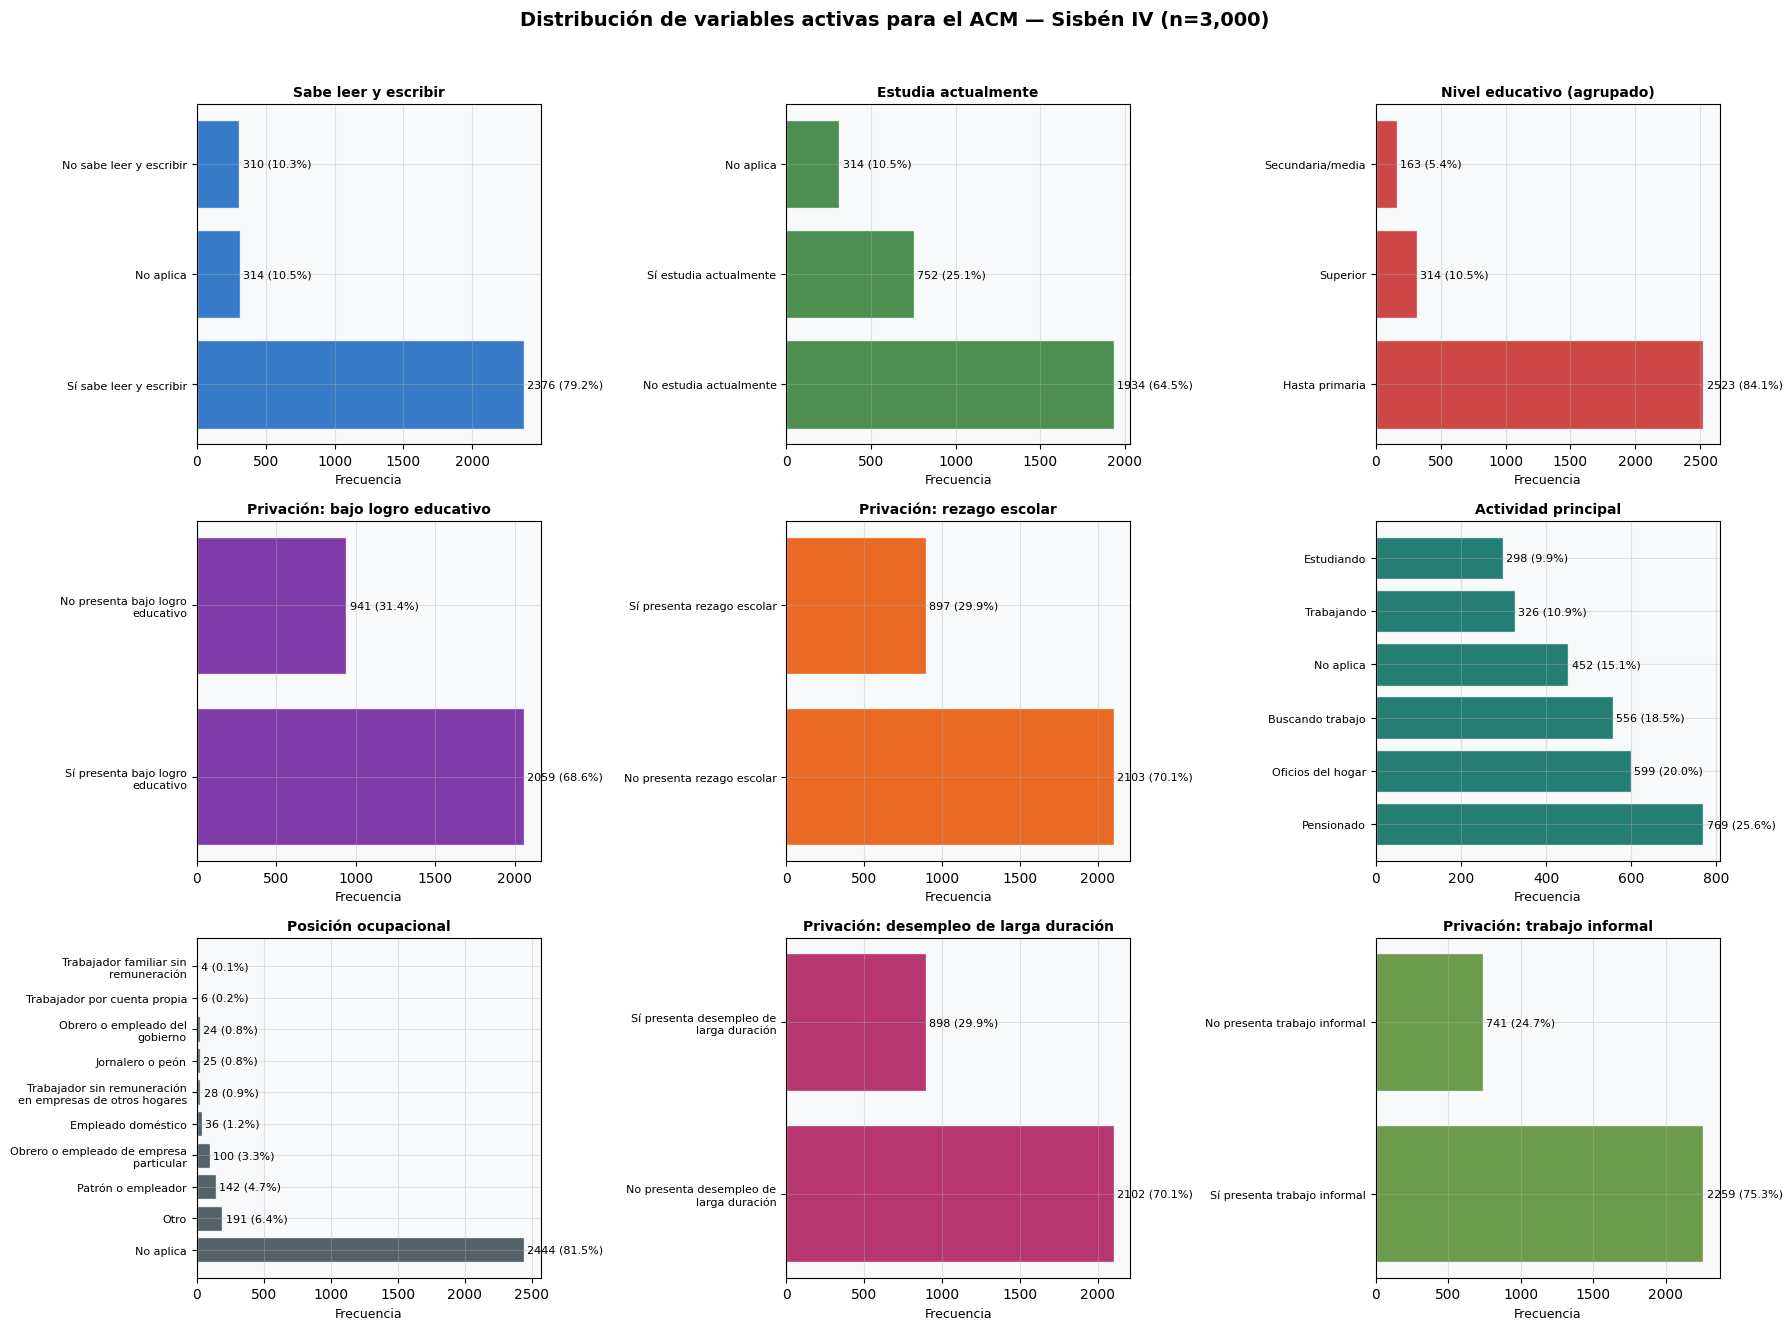

In [25]:
# ── Distribución de variables activas ───────────────────────────────────────

titulos = {
    'LEER': 'Sabe leer y escribir',
    'ESTUDIA': 'Estudia actualmente',
    'NIV_EDU': 'Nivel educativo (agrupado)',
    'I1_EDU': 'Privación: bajo logro educativo',
    'I4_REZ': 'Privación: rezago escolar',
    'ACTIVIDAD': 'Actividad principal',
    'POSICION_OC': 'Posición ocupacional',
    'I7_DEMP': 'Privación: desempleo de larga duración',
    'I8_INF': 'Privación: trabajo informal'
}

colores = [
    '#1565C0', '#2E7D32', '#C62828',
    '#6A1B9A', '#E65100', '#00695C',
    '#37474F', '#AD1457', '#558B2F'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(VARS_ACTIVAS, colores)):
    ax = axes[i]
    
    counts = df_final[var].value_counts(dropna=False)
    
    etiquetas = [
        '\n'.join(textwrap.wrap(str(cat), width=28))
        for cat in counts.index
    ]
    
    bars = ax.barh(
        etiquetas,
        counts.values,
        color=color,
        alpha=0.85,
        edgecolor='white'
    )
    
    ax.set_title(titulos[var], fontsize=10, fontweight='bold')
    ax.set_xlabel('Frecuencia', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    
    for bar, val in zip(bars, counts.values):
        pct = val / len(df_final) * 100
        ax.text(
            bar.get_width() + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val} ({pct:.1f}%)',
            va='center',
            fontsize=8
        )

plt.suptitle(
    f'Distribución de variables activas para el ACM — Sisbén IV (n={len(df_final):,})',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## 4.2 Construcción de Matrices

### Matriz Indicadora $Z$

Mediante **one-hot encoding** se construye $Z$ de dimensión $n \times J$ donde $J$ es el total de categorías:

$$Z = [Z_1 | Z_2 | \cdots | Z_Q]$$

### Matriz de Burt $B = Z^T Z$

Matriz simétrica que recoge todas las **tabulaciones cruzadas** entre variables. En la diagonal: frecuencias de cada categoría. Fuera: co-ocurrencias.

### Matriz de Residuos Estandarizados

$$S = D_r^{-1/2}\,(P - r c^T)\,D_c^{-1/2}$$

- $r_{ij} > +2$: **atracción** significativa entre categorías $i$ y $j$
- $r_{ij} < -2$: **repulsión** significativa


# Preguntas Guía — Sección 4.2

## 1. ¿Qué representa la Matriz de Burt?

La **Matriz de Burt** es una matriz simétrica que contiene todas las **tabulaciones cruzadas entre las categorías de las variables** incluidas en el análisis.

Se define como:

$$
B = Z^T Z
$$

donde:

- $Z$ es la matriz indicadora (one-hot encoding)  
- $B$ tiene dimensión $J \times J$, siendo $J$ el total de categorías  

### Interpretación:

- 🔹 **Diagonal**: frecuencia de cada categoría  
- 🔹 **Fuera de la diagonal**: número de veces que dos categorías aparecen juntas (co-ocurrencias)  

En otras palabras: la matriz de Burt resume **cómo se relacionan todas las categorías entre sí** en un solo objeto.


## 2. ¿Qué son los residuos estandarizados y qué indican?

Los **residuos estandarizados** miden la diferencia entre:

- lo que **realmente ocurre (observado)**  
- y lo que **se esperaría si no hubiera relación entre variables (esperado)**  

Se calculan como:

$$
S = D_r^{-1/2}\,(P - r c^T)\,D_c^{-1/2}
$$

### Interpretación:

- $S_{ij} > +2$ → **Asociación positiva fuerte (atracción)**  
- $S_{ij} < -2$ → **Asociación negativa (repulsión)**  
- $S_{ij} \approx 0$ → **Independencia**  

Indican qué combinaciones de categorías son **más frecuentes o menos frecuentes de lo esperado**.



## 3. ¿Qué significa comparar valores observados con valores esperados?

Significa evaluar si dos categorías están relacionadas o no.

- 🔹 **Valor observado ($O_{ij}$)**: cuántas veces aparecen juntas en los datos  
- 🔹 **Valor esperado ($E_{ij}$)**: cuántas veces deberían aparecer juntas **si fueran independientes**  

$$
E_{ij} = r_i \cdot c_j
$$

Entonces:

- Si $O_{ij} > E_{ij}$ → hay más relación de la esperada  
- Si $O_{ij} < E_{ij}$ → hay menos relación de la esperada  

## 4. ¿Qué indica un residuo positivo o negativo?

- **Residuo positivo ($>0$)**  
  → Las categorías aparecen juntas **más de lo esperado**  
  → Existe **asociación o afinidad**  

- **Residuo negativo ($<0$)**  
  → Las categorías aparecen juntas **menos de lo esperado**  
  → Existe **rechazo o disociación**  


##  Nota para el informe

La matriz de Burt permite sintetizar las relaciones entre todas las categorías del conjunto de variables, mientras que los residuos estandarizados permiten identificar asociaciones significativas entre ellas, comparando las frecuencias observadas con aquellas esperadas bajo independencia.


## Conclusión

Estas matrices constituyen la base del Análisis de Correspondencia Múltiple, ya que permiten transformar las relaciones categóricas en una estructura algebraica que posteriormente es descompuesta mediante técnicas espectrales para obtener las dimensiones factoriales.

In [26]:
# ── Matriz Indicadora y Matriz de Burt ──────────────────────────────────────

# Base para ACM: solo variables activas
df_acm = df_final[VARS_ACTIVAS].copy()

# Matriz indicadora Z
Z = pd.get_dummies(df_acm, columns=VARS_ACTIVAS, dtype=int)

# Pasar a arreglo numérico
Z_arr = Z.values.astype(float)

# Matriz de Burt: B = Z'Z
B = Z_arr.T @ Z_arr

print(f'Matriz Indicadora Z: {Z.shape} ({Z.shape[0]} individuos × {Z.shape[1]} categorías)')
print(f'Matriz de Burt B: {B.shape} (simétrica: {np.allclose(B, B.T)})')

Matriz Indicadora Z: (3000, 33) (3000 individuos × 33 categorías)
Matriz de Burt B: (33, 33) (simétrica: True)


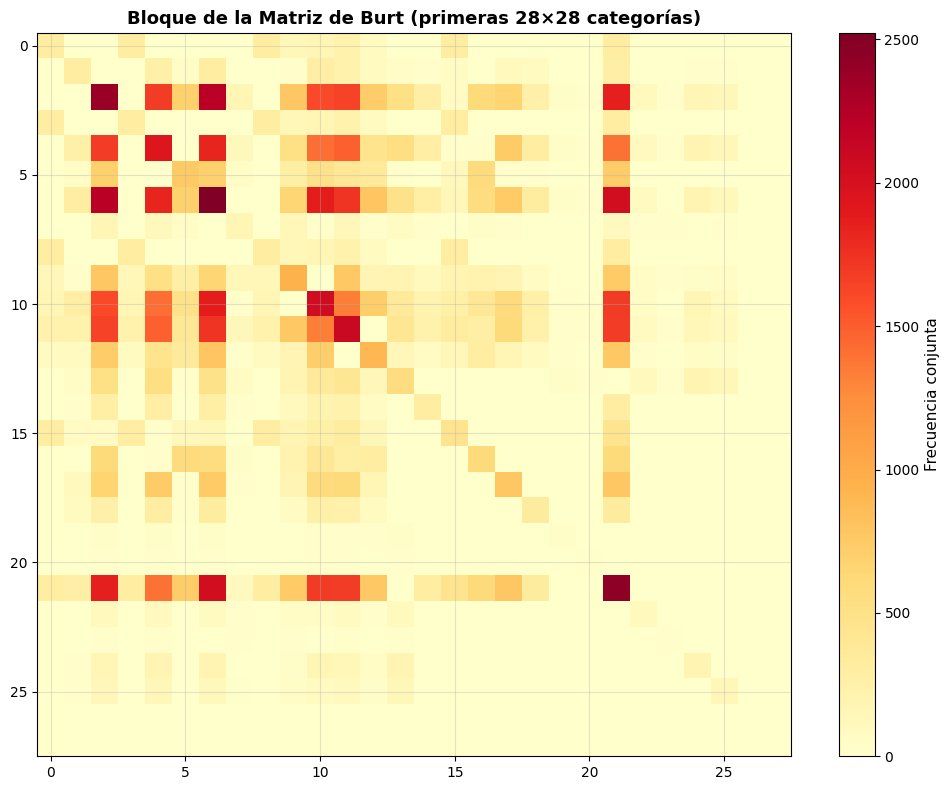

In [27]:
# ── Visualización de un bloque de la Matriz de Burt ─────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

block = min(28, B.shape[0])  # mostrar solo una parte si hay muchas categorías
im = ax.imshow(B[:block, :block], cmap='YlOrRd', aspect='auto')

ax.set_title(
    f'Bloque de la Matriz de Burt (primeras {block}×{block} categorías)',
    fontweight='bold'
)

plt.colorbar(im, ax=ax, label='Frecuencia conjunta')
plt.tight_layout()
plt.show()

In [28]:
# ── Matriz de Burt con etiquetas ────────────────────────────────────────────

B_df = pd.DataFrame(B, index=Z.columns, columns=Z.columns)

print(B_df.iloc[:10, :10])

                                         LEER_No aplica  \
LEER_No aplica                                    314.0   
LEER_No sabe leer y escribir                        0.0   
LEER_Sí sabe leer y escribir                        0.0   
ESTUDIA_No aplica                                 314.0   
ESTUDIA_No estudia actualmente                      0.0   
ESTUDIA_Sí estudia actualmente                      0.0   
NIV_EDU_Hasta primaria                              0.0   
NIV_EDU_Secundaria/media                            0.0   
NIV_EDU_Superior                                  314.0   
I1_EDU_No presenta bajo logro educativo           145.0   

                                         LEER_No sabe leer y escribir  \
LEER_No aplica                                                    0.0   
LEER_No sabe leer y escribir                                    310.0   
LEER_Sí sabe leer y escribir                                      0.0   
ESTUDIA_No aplica                                         

### Interpretación de la matriz de Burt

La matriz de Burt permite observar la frecuencia conjunta entre categorías de las variables analizadas. Los elementos diagonales corresponden a las frecuencias marginales, mientras que los elementos fuera de la diagonal representan co-ocurrencias entre categorías.

Asimismo, se evidencian patrones relevantes como la presencia de individuos con educación primaria que no saben leer y escribir, lo cual sugiere rezagos en la calidad educativa.

Por otro lado, se detecta un grupo de observaciones con categorías "No aplica" que presentan coincidencias exactas entre variables, lo cual indica posibles dependencias entre estas y no seria una relacion real entre categorias.

## 4.3 Descomposición en Valores Singulares (DVS)

El núcleo matemático del Análisis de Correspondencia Múltiple (ACM) es la **Descomposición en Valores Singulares (DVS)** aplicada a la matriz de residuos estandarizados:

$$
S = U \cdot D \cdot V^T
$$

Esta descomposición permite representar la estructura de relaciones entre categorías e individuos en un espacio de menor dimensión, conservando la mayor parte de la información relevante.

---

### Interpretación de las matrices

| Matriz | Dimensión | Interpretación |
|--------|----------|----------------|
| $U$ | $n \times k$ | Coordenadas de los **individuos** en el espacio factorial |
| $D$ | $k \times k$ | Matriz diagonal con los **valores singulares** $\mu_k$ |
| $V$ | $J \times k$ | Coordenadas de las **categorías** en el espacio factorial |

---

###Valores singulares y autovalores

Los valores singulares $\mu_k$ permiten obtener los **autovalores**:

$$
\lambda_k = \mu_k^2
$$

Estos autovalores representan la **inercia explicada** por cada dimensión, es decir, la proporción de variabilidad capturada por cada eje factorial.

---

### Interpretación en el contexto del ACM

- Cada dimensión (factor) resume un patrón de asociación entre categorías.
- Las primeras dimensiones concentran la mayor parte de la información.
- La proyección en pocas dimensiones permite visualizar relaciones complejas de forma simple.

En otras palabras, la DVS transforma un problema de alta dimensión en un espacio reducido donde las relaciones entre categorías son interpretables.

---

## Preguntas Guía — Sección 4.3

### 1. ¿Qué es la DVS?

La Descomposición en Valores Singulares (DVS) es una técnica algebraica que factoriza una matriz en tres componentes, permitiendo identificar las direcciones principales de variación en los datos.

---

### 2. ¿Qué representan las matrices $U$, $D$ y $V$?

- $U$: representa la posición de los individuos en el espacio reducido  
- $D$: contiene la magnitud de la variabilidad (valores singulares)  
- $V$: representa la posición de las categorías en el espacio factorial  

---

### 3. ¿Por qué la DVS permite reducir la dimensionalidad?

Porque ordena las dimensiones según su importancia (inercia).  
Las primeras dimensiones concentran la mayor parte de la información, lo que permite trabajar con menos variables sin perder capacidad explicativa.

---

### 4. ¿Qué relación existe entre valores singulares y autovalores?

Los autovalores se obtienen como el cuadrado de los valores singulares:

$$
\lambda_k = \mu_k^2
$$

Estos cuantifican la cantidad de inercia explicada por cada dimensión, siendo fundamentales para decidir cuántas dimensiones conservar en el análisis.

---

## Nota

La DVS constituye el paso fundamental del ACM, ya que permite identificar las dimensiones latentes que estructuran las relaciones entre categorías, facilitando su representación e interpretación en un espacio de baja dimensión.

In [32]:

# Base del ACM: solo variables activas
df_acm = df_final[VARS_ACTIVAS].copy()

# Ajuste del modelo
mca = prince.MCA(
    n_components=6,
    n_iter=10,
    random_state=42
)

mca = mca.fit(df_acm)

# Autovalores e inercia
eigenvalues = np.array(mca.eigenvalues_)
inercia_pct = 100 * eigenvalues / eigenvalues.sum()
inercia_acum = np.cumsum(inercia_pct)

# Número de variables activas
Q = len(VARS_ACTIVAS)

# Umbral tipo Kaiser para ACM
umbral_k = 1 / Q

print('=' * 60)
print(' Tabla de autovalores e inercia del ACM')
print('=' * 60)
print(f'{"Dim":>4} {"λ":>14} {"Inercia %":>11} {"Acumulada %":>13}')
print('-' * 52)

for k, (ev, pct, ac) in enumerate(zip(eigenvalues, inercia_pct, inercia_acum), start=1):
    marca = ' ← Kaiser' if ev > umbral_k else ''
    print(f'{k:>4} {ev:>14.5f} {pct:>10.2f}% {ac:>12.2f}%{marca}')

print(f'\nUmbral Kaiser (1/{Q}): {umbral_k:.4f}')
if len(inercia_acum) >= 2:
    print(f'Inercia acumulada Dim1 + Dim2: {inercia_acum[1]:.2f}%')

 Tabla de autovalores e inercia del ACM
 Dim              λ   Inercia %   Acumulada %
----------------------------------------------------
   1        0.42241      30.61%        30.61% ← Kaiser
   2        0.26112      18.92%        49.53% ← Kaiser
   3        0.22381      16.22%        65.74% ← Kaiser
   4        0.19329      14.01%        79.75% ← Kaiser
   5        0.15904      11.52%        91.27% ← Kaiser
   6        0.12045       8.73%       100.00% ← Kaiser

Umbral Kaiser (1/9): 0.1111
Inercia acumulada Dim1 + Dim2: 49.53%


## Criterio de Kaiser
El criterio de Kaiser es una regla para decidir cuántas dimensiones (factores) conservar en un análisis como PCA o ACM.

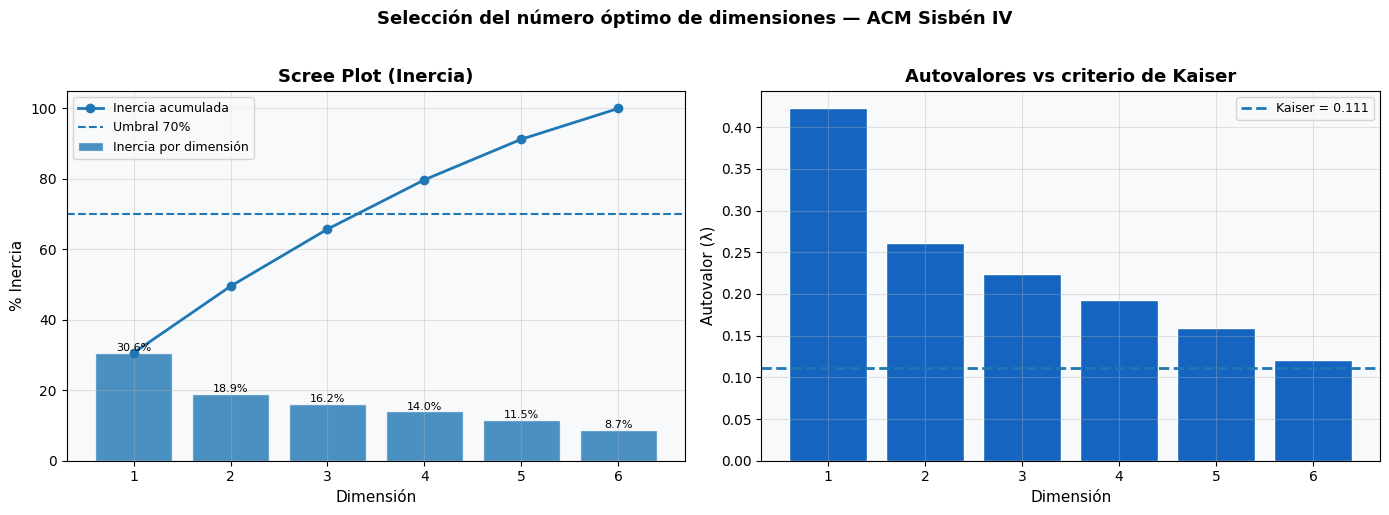

In [33]:
# ── Scree Plot ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

dims = np.arange(1, len(eigenvalues) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Inercia ──────────────────────────────────────────────────────
ax1.bar(
    dims,
    inercia_pct,
    alpha=0.8,
    edgecolor='white',
    label='Inercia por dimensión'
)

ax1.plot(
    dims,
    inercia_acum,
    'o-',
    lw=2,
    ms=6,
    label='Inercia acumulada'
)

ax1.axhline(70, linestyle='--', lw=1.5, label='Umbral 70%')

# Etiquetas
for i, (p, a) in enumerate(zip(inercia_pct, inercia_acum)):
    ax1.text(i+1, p + 0.5, f'{p:.1f}%', ha='center', fontsize=8)

ax1.set_xticks(dims)
ax1.set_xlabel('Dimensión')
ax1.set_ylabel('% Inercia')
ax1.set_title('Scree Plot (Inercia)', fontweight='bold')
ax1.legend(fontsize=9)

# ── Gráfico 2: Autovalores vs Kaiser ─────────────────────────────────────────
colores_barras = [
    '#1565C0' if ev > umbral_k else '#B0BEC5'
    for ev in eigenvalues
]

ax2.bar(
    dims,
    eigenvalues,
    color=colores_barras,
    edgecolor='white'
)

ax2.axhline(
    umbral_k,
    linestyle='--',
    lw=2,
    label=f'Kaiser = {umbral_k:.3f}'
)

ax2.set_xticks(dims)
ax2.set_xlabel('Dimensión')
ax2.set_ylabel('Autovalor (λ)')
ax2.set_title('Autovalores vs criterio de Kaiser', fontweight='bold')
ax2.legend(fontsize=9)

# ── Título general ───────────────────────────────────────────────────────────
plt.suptitle(
    'Selección del número óptimo de dimensiones — ACM Sisbén IV',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

---
## 4.5 Visualización e Interpretación: Biplot

| Observación geométrica | Interpretación |
|------------------------|----------------|
| Dos categorías **muy cercanas** | Tienden a aparecer en los mismos individuos |
| Categorías en **extremos opuestos** | Definen el contraste del eje |
| Punto **cerca del origen** | Comportamiento promedio, sin rasgo distintivo |
| Punto **lejos del origen** | Perfil muy atípico |

### Principio del centroide
- Individuo = promedio ponderado de sus categorías.
- Categoría = promedio ponderado de los individuos que la responden.

---

## 🔑 Preguntas Guía — Sección 4.5

> 1. ¿Cómo se interpretan las distancias entre puntos en el plano factorial?
> 2. ¿Qué significa que dos categorías estén cerca?
> 3. ¿Qué representa el origen?
> 4. ¿Qué es un biplot y qué información proporciona?
> 5. ¿Qué significa la polaridad de un eje?
> 6. ¿Qué indica que un punto esté lejos del origen?

In [34]:
# ── Coordenadas del biplot ───────────────────────────────────────────────────
cat_coords = mca.column_coordinates(df_acm).copy()
ind_coords = mca.row_coordinates(df_acm).copy()

# ── Extraer variable de cada categoría (robusto) ─────────────────────────────
cat_var = []

for col in cat_coords.index:
    encontrado = False
    
    for v in VARS_ACTIVAS:
        # Prince usa formato: VARIABLE__categoria
        if col.startswith(v + '__') or col.startswith(v + '='):
            cat_var.append(v)
            encontrado = True
            break
    
    if not encontrado:
        cat_var.append('Otro')

cat_coords['Variable'] = cat_var

# ── Paleta de colores por variable ───────────────────────────────────────────
pal = plt.cm.get_cmap('tab10', len(VARS_ACTIVAS))
cmap_v = {v: pal(i) for i, v in enumerate(VARS_ACTIVAS)}

# ── Resumen ──────────────────────────────────────────────────────────────────
print(f'✅ Coordenadas: {cat_coords.shape[0]} categorías · {ind_coords.shape[0]} individuos')

✅ Coordenadas: 33 categorías · 3000 individuos


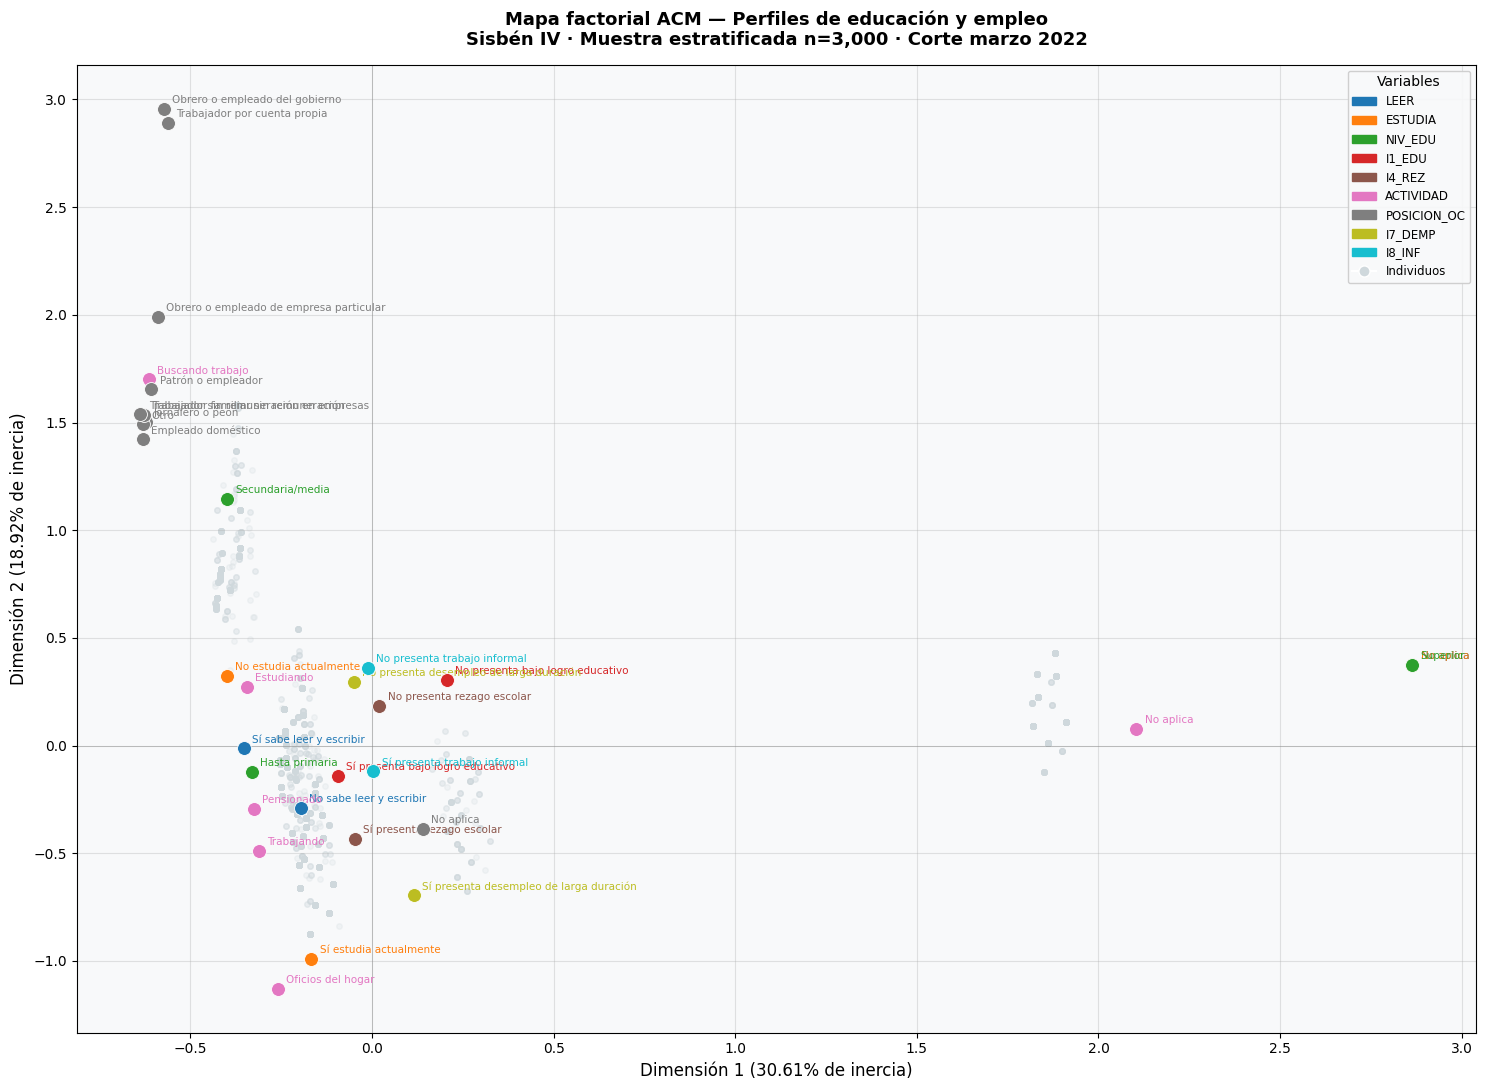

In [35]:
# ── Biplot principal ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 11))

# Ejes de referencia
ax.axhline(0, color='gray', lw=0.7, alpha=0.4)
ax.axvline(0, color='gray', lw=0.7, alpha=0.4)

# ── Individuos ───────────────────────────────────────────────────────────────
ax.scatter(
    ind_coords.iloc[:, 0],
    ind_coords.iloc[:, 1],
    color='#CFD8DC',
    alpha=0.20,
    s=16,
    zorder=1,
    label='Individuos'
)

# ── Categorías ───────────────────────────────────────────────────────────────
for var in VARS_ACTIVAS:
    sub = cat_coords[cat_coords['Variable'] == var].copy()
    c = cmap_v[var]

    ax.scatter(
        sub.iloc[:, 0],
        sub.iloc[:, 1],
        color=c,
        s=100,
        zorder=4,
        edgecolors='white',
        linewidths=0.6
    )

    for idx, row in sub.iterrows():
        # Prince suele usar VARIABLE__categoria
        lbl = str(idx)
        lbl = lbl.replace(var + '__', '').replace(var + '_', '').replace(var + '=', '')
        lbl = lbl[:40]

        ax.annotate(
            lbl,
            xy=(row.iloc[0], row.iloc[1]),
            xytext=(6, 4),
            textcoords='offset points',
            fontsize=7.5,
            color=c,
            fontweight='medium'
        )

# ── Leyenda ──────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(color=cmap_v[v], label=v) for v in VARS_ACTIVAS]
handles.append(
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#CFD8DC',
        markersize=8,
        label='Individuos'
    )
)

ax.legend(
    handles=handles,
    loc='upper right',
    fontsize=8.5,
    framealpha=0.92,
    title='Variables'
)

# ── Etiquetas de ejes ────────────────────────────────────────────────────────
ax.set_xlabel(f'Dimensión 1 ({inercia_pct[0]:.2f}% de inercia)', fontsize=12)
ax.set_ylabel(f'Dimensión 2 ({inercia_pct[1]:.2f}% de inercia)', fontsize=12)

# OJO: usa df_acm o df_final, no df crudo
ax.set_title(
    f'Mapa factorial ACM — Perfiles de educación y empleo\n'
    f'Sisbén IV · Muestra estratificada n={len(df_acm):,} · Corte marzo 2022',
    fontsize=13,
    fontweight='bold',
    pad=14
)

plt.tight_layout()
plt.show()

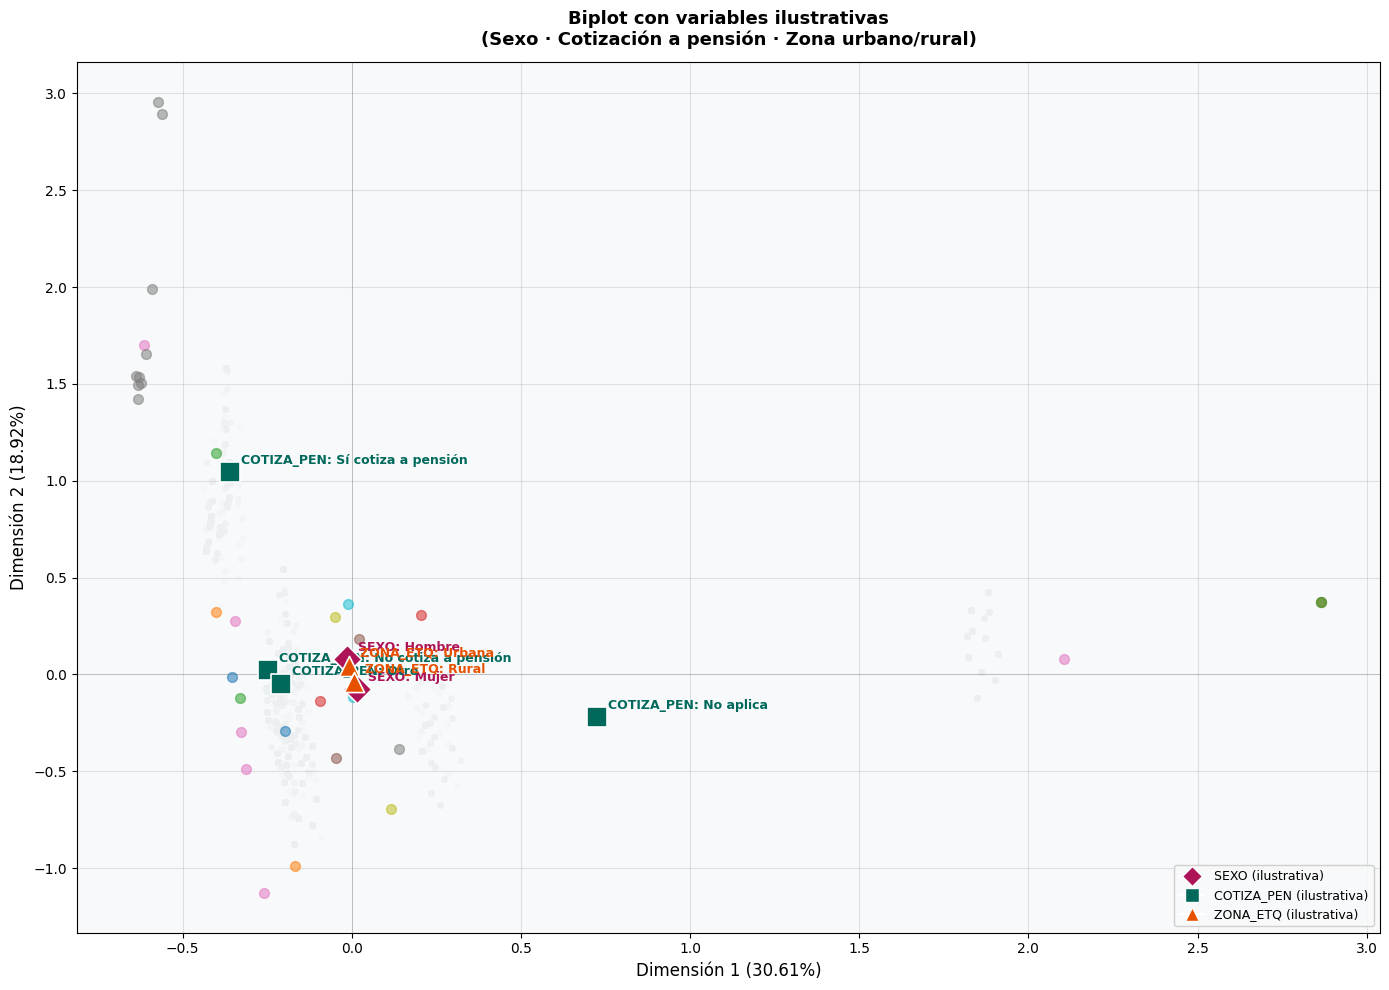

In [36]:
# ── Proyección de variables ilustrativas ─────────────────────────────────────
# Se calcula como el centroide (promedio) de coordenadas de individuos
# que pertenecen a cada categoría ilustrativa.


# Base alineada con el ACM: activas + ilustrativas
df_plot = df_final[VARS_ACTIVAS + VARS_ILUSTR].copy()

MAP_COL = {
    'SEXO': 'SEXO',
    'COTIZA_PEN': 'COTIZA_PEN',
    'ZONA_ETQ': 'ZONA_ETQ'
}

MRK = {
    'SEXO': 'D',
    'COTIZA_PEN': 's',
    'ZONA_ETQ': '^'
}

COL_ILUS = {
    'SEXO': '#AD1457',
    'COTIZA_PEN': '#00695C',
    'ZONA_ETQ': '#E65100'
}

fig, ax = plt.subplots(figsize=(14, 10))

# Ejes de referencia
ax.axhline(0, color='gray', lw=0.6, alpha=0.4)
ax.axvline(0, color='gray', lw=0.6, alpha=0.4)

# ── Individuos de fondo ──────────────────────────────────────────────────────
ax.scatter(
    ind_coords.iloc[:, 0],
    ind_coords.iloc[:, 1],
    color='#ECEFF1',
    alpha=0.18,
    s=14,
    zorder=1
)

# ── Categorías activas (pequeñas) ────────────────────────────────────────────
for var in VARS_ACTIVAS:
    sub = cat_coords[cat_coords['Variable'] == var]
    ax.scatter(
        sub.iloc[:, 0],
        sub.iloc[:, 1],
        color=cmap_v[var],
        s=50,
        alpha=0.55,
        zorder=3
    )

# ── Variables ilustrativas como centroides ───────────────────────────────────
for v_ilus in VARS_ILUSTR:
    col = MAP_COL[v_ilus]

    for cat in df_plot[col].dropna().unique():
        mask = df_plot[col] == cat

        x = ind_coords.loc[mask, 0].mean()
        y = ind_coords.loc[mask, 1].mean()

        ax.scatter(
            x, y,
            marker=MRK[v_ilus],
            color=COL_ILUS[v_ilus],
            s=210,
            zorder=6,
            edgecolors='white',
            linewidths=1.2
        )

        ax.annotate(
            f'{v_ilus}: {cat}',
            xy=(x, y),
            xytext=(8, 6),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color=COL_ILUS[v_ilus]
        )

# ── Leyenda ──────────────────────────────────────────────────────────────────
hl = [
    plt.Line2D([0], [0], marker='D', color='w',
               markerfacecolor='#AD1457', markersize=10,
               label='SEXO (ilustrativa)'),
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor='#00695C', markersize=10,
               label='COTIZA_PEN (ilustrativa)'),
    plt.Line2D([0], [0], marker='^', color='w',
               markerfacecolor='#E65100', markersize=10,
               label='ZONA_ETQ (ilustrativa)')
]

ax.legend(handles=hl, loc='lower right', fontsize=9, framealpha=0.92)

ax.set_xlabel(f'Dimensión 1 ({inercia_pct[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Dimensión 2 ({inercia_pct[1]:.2f}%)', fontsize=12)

ax.set_title(
    'Biplot con variables ilustrativas\n'
    '(Sexo · Cotización a pensión · Zona urbano/rural)',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.show()

# 5. Resultados

## Interpretación de los ejes

Para interpretar cada dimensión del ACM se analizan las categorías ubicadas en los extremos de los ejes factoriales:

- **Polo positivo (+)**: categorías con coordenadas más altas → definen un perfil específico.
- **Polo negativo (−)**: categorías con coordenadas más bajas → representan el perfil contrastante.

Estas posiciones reflejan patrones de asociación entre categorías, permitiendo identificar estructuras latentes en los datos.

---

## Dimensión 1: Gradiente socioeconómico y educativo

La primera dimensión concentra la mayor proporción de la inercia total, por lo que representa el eje principal de diferenciación en la población.

- **Polo negativo (−)**:
  - Categorías asociadas a **bajo nivel educativo** (ej. *Sin educación*, *Hasta primaria*)
  - Presencia de **privaciones** (rezago escolar, bajo logro educativo)
  - Condiciones de **informalidad laboral** o inactividad

- **Polo positivo (+)**:
  - Categorías de **mayor nivel educativo** (secundaria/media, superior)
  - Ausencia de privaciones educativas
  - Mayor vinculación al mercado laboral formal

 **Interpretación**:  
Este eje refleja un **gradiente socioeconómico**, donde se contraponen individuos en condiciones de vulnerabilidad educativa y laboral frente a aquellos con mayor capital humano y mejores condiciones de inserción laboral.

---

## Dimensión 2: Participación educativa y ciclo de vida

La segunda dimensión captura diferencias relacionadas con la participación en el sistema educativo y la etapa del ciclo de vida.

- **Polo negativo (−)**:
  - Personas que **no estudian actualmente**
  - Mayor presencia en actividades laborales o de inactividad

- **Polo positivo (+)**:
  - Personas que **sí estudian actualmente**
  - Asociadas principalmente a niveles educativos en curso

**Interpretación**:  
Este eje distingue entre individuos en etapa de formación (estudiantes) y aquellos que ya han transitado al mercado laboral o a otras actividades.

---

## Síntesis interpretativa

En conjunto, las dos primeras dimensiones permiten identificar perfiles diferenciados en la población:

- Un eje principal asociado a **desigualdades estructurales en educación y empleo**
- Un eje secundario relacionado con la **participación en el sistema educativo**

La combinación de ambos ejes facilita la identificación de grupos con características socioeconómicas similares, lo que constituye la base para el análisis de perfiles laborales en función de sus condiciones educativas y de privación.

---

## Nota metodológica

Se debe considerar que la presencia de categorías como *“No aplica”* puede introducir dependencias estructurales que afecten la interpretación de los ejes, por lo que su tratamiento adecuado es fundamental para garantizar la estabilidad del análisis.

In [37]:
# ── Polaridades por dimensión ────────────────────────────────────────────────
cat_num = cat_coords.iloc[:, :2].copy()
cat_num.columns = ['Dim1', 'Dim2']
cat_num['Variable'] = cat_coords['Variable'].values

for dim in ['Dim1', 'Dim2']:
    print(f'\n{"="*60}')
    print(f' DIMENSIÓN {dim[-1]} — Top 5 por polo')
    print(f'{"="*60}')
    
    for label, fn in [("Polo (+)", 'nlargest'), ("Polo (−)", 'nsmallest')]:
        top = getattr(cat_num, fn)(5, dim)[[dim, 'Variable']]
        
        print(f'\n  {label}:')
        for idx, row in top.iterrows():
            lbl = str(idx)
            lbl = lbl.replace(row['Variable'] + '__', '')
            lbl = lbl.replace(row['Variable'] + '_', '')
            lbl = lbl.replace(row['Variable'] + '=', '')
            lbl = lbl[:50]
            
            print(f'    {row[dim]:+.4f}  [{row["Variable"]}]  {lbl}')


 DIMENSIÓN 1 — Top 5 por polo

  Polo (+):
    +2.8643  [LEER]  No aplica
    +2.8643  [ESTUDIA]  No aplica
    +2.8643  [NIV_EDU]  Superior
    +2.1045  [ACTIVIDAD]  No aplica
    +0.2060  [I1_EDU]  No presenta bajo logro educativo

  Polo (−):
    -0.6371  [POSICION_OC]  Trabajador sin remuneración en empresas de otros h
    -0.6308  [POSICION_OC]  Otro
    -0.6303  [POSICION_OC]  Empleado doméstico
    -0.6278  [POSICION_OC]  Trabajador familiar sin remuneración
    -0.6232  [POSICION_OC]  Jornalero o peón

 DIMENSIÓN 2 — Top 5 por polo

  Polo (+):
    +2.9570  [POSICION_OC]  Obrero o empleado del gobierno
    +2.8927  [POSICION_OC]  Trabajador por cuenta propia
    +1.9916  [POSICION_OC]  Obrero o empleado de empresa particular
    +1.7004  [ACTIVIDAD]  Buscando trabajo
    +1.6540  [POSICION_OC]  Patrón o empleador

  Polo (−):
    -1.1293  [ACTIVIDAD]  Oficios del hogar
    -0.9903  [ESTUDIA]  Sí estudia actualmente
    -0.6955  [I7_DEMP]  Sí presenta desempleo de larga duració

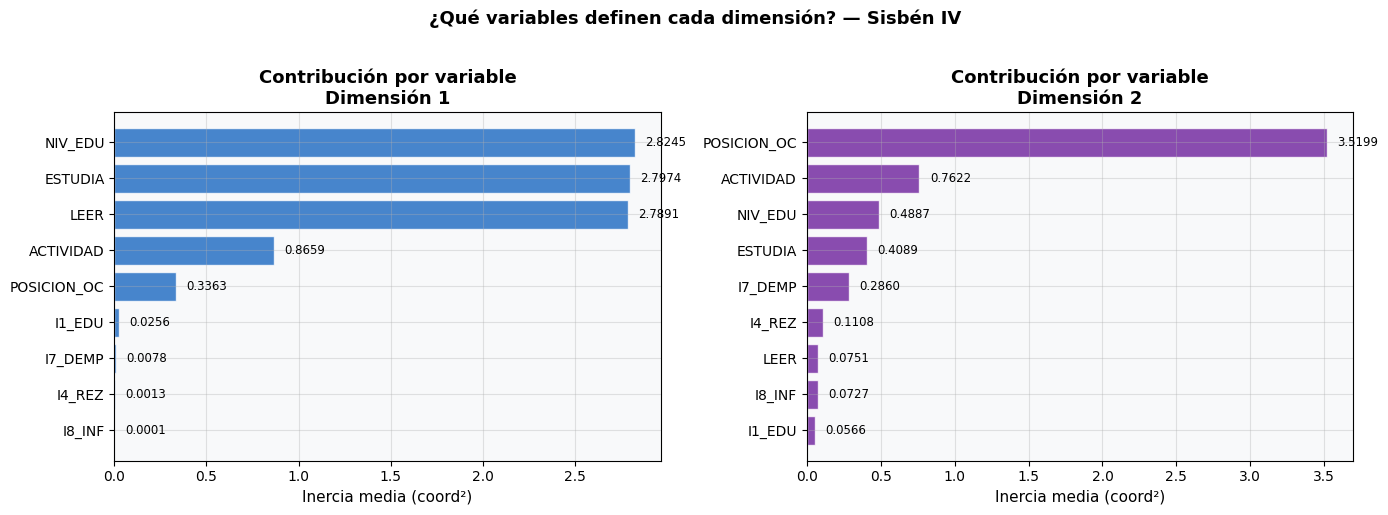

In [38]:
# ── Contribución aproximada de variables por dimensión ───────────────────────
# Se usa la media de coord² por categoría dentro de cada variable

contrib_d1 = cat_num.groupby('Variable')['Dim1'].apply(lambda x: (x**2).mean())
contrib_d2 = cat_num.groupby('Variable')['Dim2'].apply(lambda x: (x**2).mean())

df_c = pd.DataFrame({
    'Dimensión 1': contrib_d1,
    'Dimensión 2': contrib_d2
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (dim, color) in enumerate([
    ('Dimensión 1', '#1565C0'),
    ('Dimensión 2', '#6A1B9A')
]):
    vals = df_c[dim].sort_values()
    
    bars = axes[i].barh(
        vals.index,
        vals.values,
        color=color,
        alpha=0.78,
        edgecolor='white'
    )
    
    axes[i].set_title(f'Contribución por variable\n{dim}', fontweight='bold')
    axes[i].set_xlabel('Inercia media (coord²)')
    
    for bar, val in zip(bars, vals.values):
        axes[i].text(
            bar.get_width() + vals.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center',
            fontsize=8.5
        )

plt.suptitle(
    '¿Qué variables definen cada dimensión? — Sisbén IV',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

=== Distribución por cuadrante ===
Cuadrante
Q3 (−,−)    1553
Q2 (−,+)     995
Q1 (+,+)     294
Q4 (+,−)     158


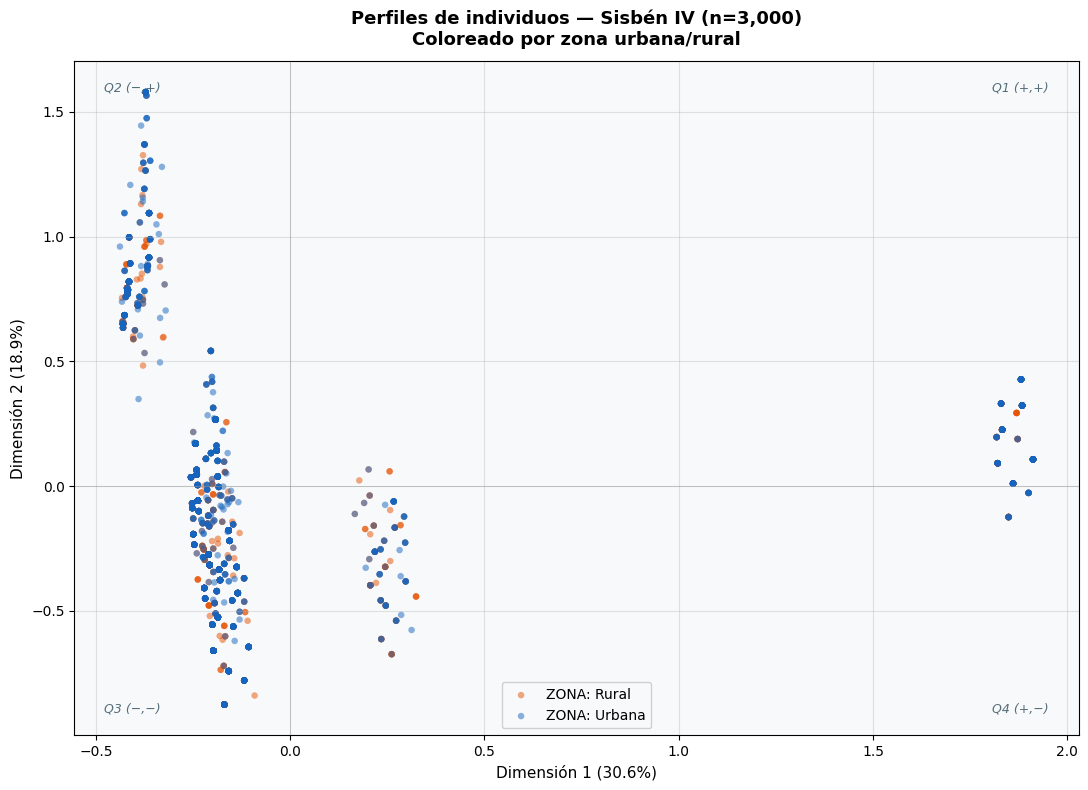

In [39]:
# ── Perfiles de individuos por cuadrante ─────────────────────────────────────
ind_df = ind_coords.iloc[:, :2].copy()
ind_df.columns = ['Dim1', 'Dim2']

# Añadir variables descriptivas desde la misma base alineada con el ACM
ind_df['ZONA'] = df_final['ZONA_ETQ'].values
ind_df['NIV_EDU'] = df_final['NIV_EDU'].values
ind_df['ACTIVIDAD'] = df_final['ACTIVIDAD'].values

# Definir cuadrantes
ind_df['Cuadrante'] = 'Q3 (−,−)'
ind_df.loc[(ind_df['Dim1'] >= 0) & (ind_df['Dim2'] >= 0), 'Cuadrante'] = 'Q1 (+,+)'
ind_df.loc[(ind_df['Dim1'] <  0) & (ind_df['Dim2'] >= 0), 'Cuadrante'] = 'Q2 (−,+)'
ind_df.loc[(ind_df['Dim1'] >= 0) & (ind_df['Dim2'] <  0), 'Cuadrante'] = 'Q4 (+,−)'

print('=== Distribución por cuadrante ===')
print(ind_df['Cuadrante'].value_counts().to_string())

# Colores correctos según tus categorías
color_zona = {
    'Urbana': '#1565C0',
    'Rural': '#E65100',
    'Otro': '#888780'
}

fig, ax = plt.subplots(figsize=(11, 8))
ax.axhline(0, color='gray', lw=0.6, alpha=0.4)
ax.axvline(0, color='gray', lw=0.6, alpha=0.4)

# Dispersión por zona
for z, grp in ind_df.groupby('ZONA'):
    c = color_zona.get(str(z), '#888780')
    ax.scatter(
        grp['Dim1'],
        grp['Dim2'],
        label=f'ZONA: {z}',
        color=c,
        s=22,
        alpha=0.5,
        edgecolors='none'
    )

# Etiquetas de cuadrantes
for txt, (px, py) in [
    ('Q1 (+,+)', (0.97, 0.97)),
    ('Q2 (−,+)', (0.03, 0.97)),
    ('Q3 (−,−)', (0.03, 0.03)),
    ('Q4 (+,−)', (0.97, 0.03))
]:
    ax.text(
        px, py, txt,
        transform=ax.transAxes,
        ha='right' if px > 0.5 else 'left',
        va='top' if py > 0.5 else 'bottom',
        fontsize=9,
        color='#546E7A',
        style='italic'
    )

ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlabel(f'Dimensión 1 ({inercia_pct[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'Dimensión 2 ({inercia_pct[1]:.1f}%)', fontsize=11)
ax.set_title(
    f'Perfiles de individuos — Sisbén IV (n={len(ind_df):,})\n'
    f'Coloreado por zona urbana/rural',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.show()

In [40]:
print('\n=== Perfil dominante por cuadrante ===')

for q, grp in ind_df.groupby('Cuadrante'):
    print(f'\n{q}')
    print('Zona más frecuente:')
    print(grp['ZONA'].value_counts(normalize=True).head(3).mul(100).round(1).astype(str) + '%')
    print('Nivel educativo más frecuente:')
    print(grp['NIV_EDU'].value_counts(normalize=True).head(3).mul(100).round(1).astype(str) + '%')
    print('Actividad más frecuente:')
    print(grp['ACTIVIDAD'].value_counts(normalize=True).head(3).mul(100).round(1).astype(str) + '%')


=== Perfil dominante por cuadrante ===

Q1 (+,+)
Zona más frecuente:
ZONA
Rural     56.5%
Urbana    43.5%
Name: proportion, dtype: str
Nivel educativo más frecuente:
NIV_EDU
Superior          98.3%
Hasta primaria     1.7%
Name: proportion, dtype: str
Actividad más frecuente:
ACTIVIDAD
No aplica    100.0%
Name: proportion, dtype: str

Q2 (−,+)
Zona más frecuente:
ZONA
Urbana    50.7%
Rural     49.3%
Name: proportion, dtype: str
Nivel educativo más frecuente:
NIV_EDU
Hasta primaria      88.2%
Secundaria/media    11.8%
Name: proportion, dtype: str
Actividad más frecuente:
ACTIVIDAD
Buscando trabajo    55.9%
Estudiando          25.9%
Pensionado          15.1%
Name: proportion, dtype: str

Q3 (−,−)
Zona más frecuente:
ZONA
Rural     57.2%
Urbana    42.8%
Name: proportion, dtype: str
Nivel educativo más frecuente:
NIV_EDU
Hasta primaria      97.0%
Secundaria/media     3.0%
Name: proportion, dtype: str
Actividad más frecuente:
ACTIVIDAD
Pensionado           39.9%
Oficios del hogar    38.6%
T

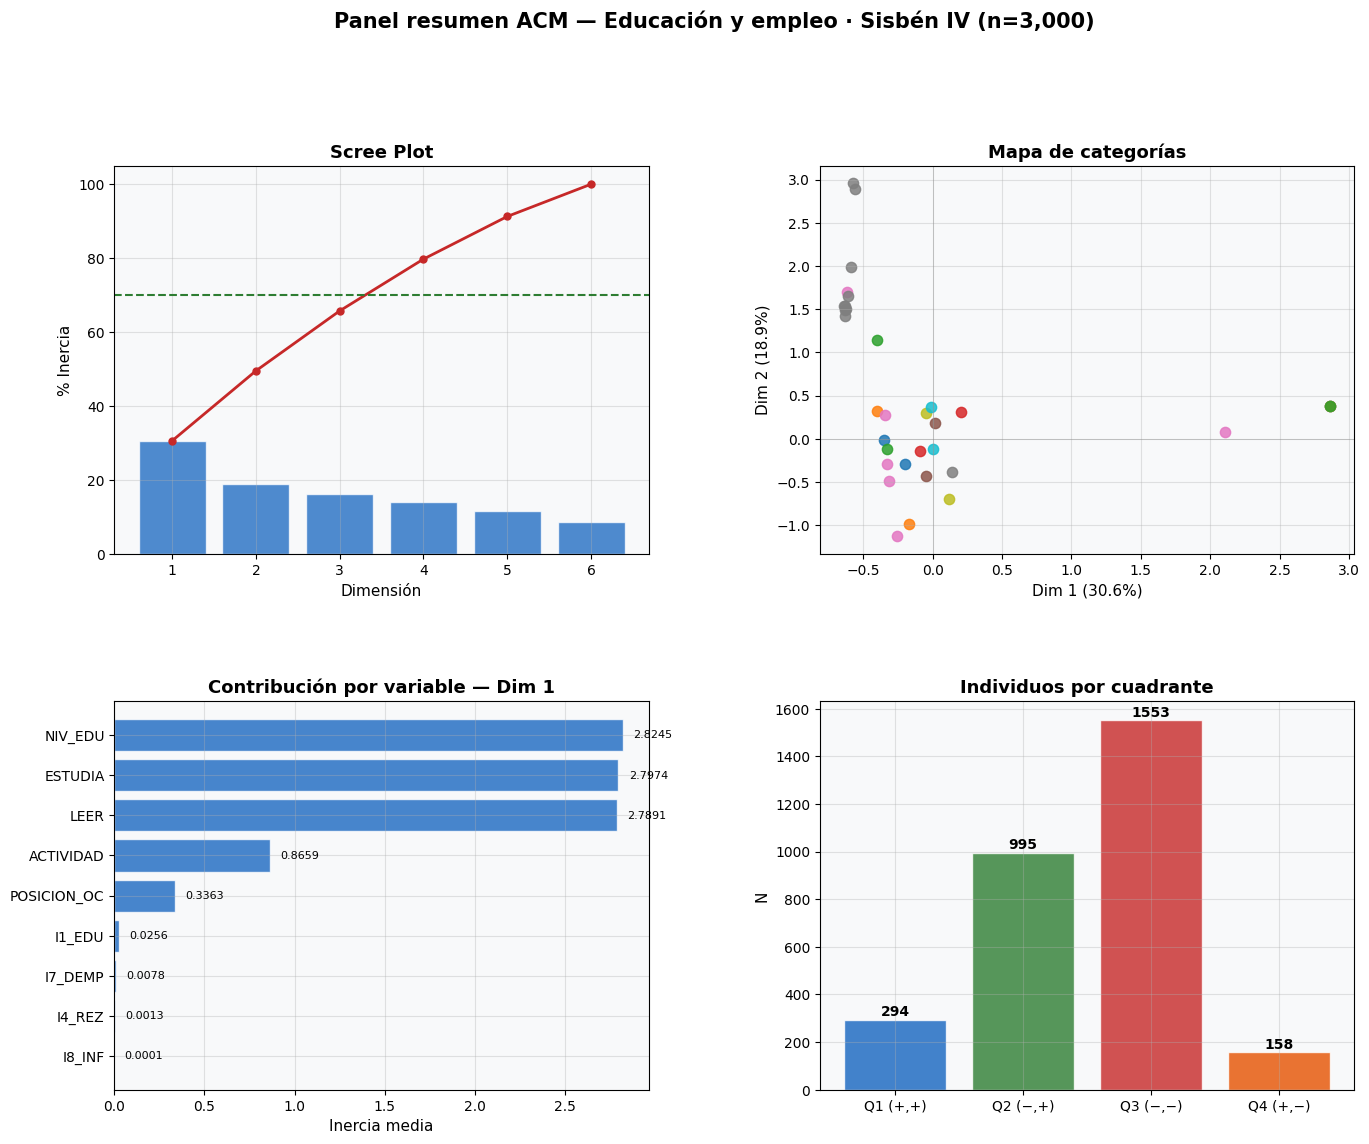


✅ Análisis completado.


In [41]:
# ── Panel resumen ────────────────────────────────────────────────────────────
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── 1. Scree plot ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(dims, inercia_pct, color='#1565C0', alpha=0.75, edgecolor='white')
ax1.plot(dims, inercia_acum, 'o-', color='#C62828', lw=2, ms=5)
ax1.axhline(70, color='#2E7D32', ls='--', lw=1.5)
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xlabel('Dimensión')
ax1.set_ylabel('% Inercia')
ax1.set_xticks(dims)

# ── 2. Mapa de categorías ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.axhline(0, color='gray', lw=0.6, alpha=0.4)
ax2.axvline(0, color='gray', lw=0.6, alpha=0.4)

for var in VARS_ACTIVAS:
    sub = cat_coords[cat_coords['Variable'] == var]
    ax2.scatter(
        sub.iloc[:, 0],
        sub.iloc[:, 1],
        color=cmap_v[var],
        s=55,
        alpha=0.85,
        label=var
    )

ax2.set_title('Mapa de categorías', fontweight='bold')
ax2.set_xlabel(f'Dim 1 ({inercia_pct[0]:.1f}%)')
ax2.set_ylabel(f'Dim 2 ({inercia_pct[1]:.1f}%)')

# ── 3. Importancia relativa por variable en Dim 1 ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
v1 = df_c['Dimensión 1'].sort_values()
bars3 = ax3.barh(v1.index, v1.values, color='#1565C0', alpha=0.78, edgecolor='white')
ax3.set_title('Contribución por variable — Dim 1', fontweight='bold')
ax3.set_xlabel('Inercia media')

for bar, val in zip(bars3, v1.values):
    ax3.text(
        bar.get_width() + v1.max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        fontsize=8
    )

# ── 4. Individuos por cuadrante ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
orden_cuad = ['Q1 (+,+)', 'Q2 (−,+)', 'Q3 (−,−)', 'Q4 (+,−)']
qc = ind_df['Cuadrante'].value_counts().reindex(orden_cuad).fillna(0)

bars4 = ax4.bar(
    qc.index,
    qc.values,
    color=['#1565C0', '#2E7D32', '#C62828', '#E65100'],
    alpha=0.8,
    edgecolor='white'
)

ax4.set_title('Individuos por cuadrante', fontweight='bold')
ax4.set_ylabel('N')

for bar, val in zip(bars4, qc.values):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(qc.values) * 0.01,
        f'{int(val)}',
        ha='center',
        fontweight='bold'
    )

# ── Título general ───────────────────────────────────────────────────────────
fig.suptitle(
    f'Panel resumen ACM — Educación y empleo · Sisbén IV (n={len(df_final):,})',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.show()
print('\n✅ Análisis completado.')

# 6. Conclusiones


## Referencias

- Greenacre, M. (2017). *Correspondence Analysis in Practice* (3rd ed.). CRC Press.
- DNP (2022). *Documentación técnica Sisbén IV*. Departamento Nacional de Planeación.
- Datos Abiertos Colombia: https://www.datos.gov.co/Estad-sticas-Nacionales/DNP-Sisb-n-Personas/hq2v-5umk
- Abdi, H. & Valentin, D. (2007). Multiple Correspondence Analysis. *Encyclopedia of Measurement and Statistics*.